In [1]:
import tensorflow as tf
print(tf.__version__)


2.13.0


In [2]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu Dec 11 00:13:05 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 561.09                 Driver Version: 561.09         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080      WDDM  |   00000000:0A:00.0  On |                  N/A |
|  0%   36C    P8             23W /  370W |    2439MiB /  10240MiB |      8%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# !pip install boruta
# !pip install smote_variants
# !pip install lime
# !pip install signaturizer

In [4]:
#import default and other essential libraries
import os
import numpy as np
import pandas as pd
import sklearn
import joblib
import pickle
import csv
import sys
import random
import seaborn as sns
from functools import reduce
import matplotlib.backends.backend_pdf
import matplotlib.pyplot as plt
import tensorflow as tf

In [5]:
#Packages to split data and other preprocessing
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn import metrics
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.decomposition import PCA
from boruta import BorutaPy
from imblearn.pipeline import Pipeline as sample_pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE

In [6]:
#Import Classifiers
from sklearn import svm
import smote_variants as sv
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

In [7]:
## Package for calculating accuracy and analysis
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.manifold import TSNE
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import roc_curve, auc, accuracy_score, roc_auc_score, cohen_kappa_score, f1_score, precision_score, recall_score, matthews_corrcoef
from sklearn.model_selection import StratifiedKFold
from lime.lime_tabular import LimeTabularExplainer

In [8]:
from signaturizer import Signaturizer
from tqdm import tqdm

In [9]:
def handle_missing_values(data):
    print('Handling missing values')
    data = data.replace([np.inf, -np.inf, "", " "], np.nan)
    data = data.replace(["", " "], np.nan)
    for i in data.columns:
        data[i] = data[i].fillna(data[i].mean())
    return data

def Feature_Signaturizer(dat):
    sig_df=pd.DataFrame()
    desc=['A','B','C','D','E']
    for dsc in tqdm(desc):
        for i in range(1,6):
            sign = Signaturizer(dsc+str(i), local=True)
            results = sign.predict(dat)
            df=pd.DataFrame(results.signature)
            for clm in list(df.columns):
                df=df.rename(columns={clm:dsc+str(i)+'_'+str(clm)})
            sig_df=pd.concat([sig_df,df],axis = 1)
    sig_df = handle_missing_values(sig_df)
    res = pd.DataFrame()
    res['smiles'] = dat
    res = pd.concat([res,sig_df],axis = 1)
    return res

In [10]:
# 指定当前的工作文件夹
import os
# 此处为google drive中的文件路径,drive为之前指定的工作根目录，要加上
os.chdir("C:/Users/Zz/Desktop/致癌性课题/00. 机器学习相关内容/zhuhao")
#load preprocessed feature file here
data = pd.read_csv(r'AID_1194_datatable_all.csv') ### features in columns,molecules in rows
# 1. 根据列名为 PUBCHEM_CID 的取值去除重复的
data = data.drop_duplicates(subset='PUBCHEM_CID')

# 2. 替换 PUBCHEM_ACTIVITY_OUTCOME 列的取值
data['PUBCHEM_ACTIVITY_OUTCOME'] = data['PUBCHEM_ACTIVITY_OUTCOME'].replace({
    'Active': 1,
    'Inactive': 0,
    'Unspecified': np.nan
})

# 将 'Status' 列名修改为 'status'
data = data.rename(columns={'PUBCHEM_ACTIVITY_OUTCOME': 'status'})

# 3. 删除 SMILES 和 PUBCHEM_ACTIVITY_OUTCOME 两列中任一有空值的行
data = data.dropna(subset=['SMILES', 'status'])

# 4. 重新设置索引
data.reset_index(drop=True, inplace=True)

# 输出处理后的数据
data

,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,SMILES,status
0,1,48413127,62805.0,C1=CC=C2C(=C1)C3=C(N2)N=C(C=C3)N,1
1,2,48413129,177.0,CC=O,0
2,3,48413130,9548611.0,C/C=N/N(C)C=O,0
3,4,48413131,5324279.0,C/C=N/O,0
4,5,48413132,178.0,CC(=O)N,0
...,...,...,...,...,...
827,856,48414663,15081.0,CC1CN(CC(O1)C)N=O,1
828,857,48414665,12001.0,CCOC(=O)N(C)N=O,1
829,858,48414668,27135.0,C1CN(C1)N=O,1
830,859,48414670,9352.0,CC(=O)NC1=CC2=C(C=C1)C3=C(C2)C=C(C=C3)NC(=O)C,1


In [11]:
# 提取 SMILES 列
data_smiles = data['SMILES']
# 使用 Feature_Signaturizer 计算特征
data_features = Feature_Signaturizer(data_smiles)

  0%|                                                                                            | 0/5 [00:00<?, ?it/s]
Parsing SMILES: 832it [00:00, 8849.08it/s]

Generating signatures:   0%|                                                                     | 0/7 [00:00<?, ?it/s]

1/1 [==============================] - 0s 47ms/step



Generating signatures:  14%|████████▋                                                    | 1/7 [00:00<00:02,  2.60it/s]

1/1 [==============================] - 0s 20ms/step



Generating signatures:  29%|█████████████████▍                                           | 2/7 [00:00<00:01,  3.20it/s]

...

1/1 [==============================] - 0s 22ms/step



Generating signatures:  86%|████████████████████████████████████████████████████▎        | 6/7 [00:01<00:00,  3.74it/s]

1/1 [==============================] - 0s 46ms/step



100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:17<00:00, 15.50s/it]

Handling missing values


In [12]:
# 保留原始的 'status' 列
data = pd.concat([data_features, data['status']], axis=1)
data.to_csv('data_1194.csv')
# 打印查看结果
print(data)

                                                smiles      A1_0      A1_1  \
0                     C1=CC=C2C(=C1)C3=C(N2)N=C(C=C3)N  0.093736  0.085740   
1                                                 CC=O -0.093480 -0.089256   
2                                        C/C=N/N(C)C=O -0.098334 -0.081190   
3                                              C/C=N/O -0.094337 -0.094267   
4                                              CC(=O)N -0.096465  0.053733   
..                                                 ...       ...       ...   
827                                  CC1CN(CC(O1)C)N=O -0.094703  0.053767   
828                                    CCOC(=O)N(C)N=O -0.100325  0.096049   
829                                        C1CN(C1)N=O -0.096751  0.042754   
830      CC(=O)NC1=CC2=C(C=C1)C3=C(C2)C=C(C=C3)NC(=O)C -0.081429  0.101074   
831  C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC...  0.094905  0.095126   

         A1_2      A1_3      A1_4      A1_5      A1_6      A1_7

In [13]:
# dropping ALL duplicate values, if any
data.drop_duplicates(subset ="smiles", keep = 'first', inplace = True, ignore_index = True)
data

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
0,C1=CC=C2C(=C1)C3=C(N2)N=C(C=C3)N,0.093736,0.085746,0.093669,-0.093733,-0.093736,-0.093322,0.093736,-0.093720,-0.093735,...,0.119321,-0.005243,-0.015744,-0.010452,0.022232,0.016749,0.094246,-0.123218,-0.099457,1
1,CC=O,-0.093479,-0.089258,0.069801,-0.090986,-0.082043,-0.043359,0.091742,-0.093448,0.089061,...,-0.116404,0.065310,-0.059638,0.008421,-0.018185,-0.046916,-0.002449,0.137647,0.030377,0
2,C/C=N/N(C)C=O,-0.098335,-0.081193,0.049595,-0.061777,-0.066672,-0.022043,0.087456,-0.098040,0.047128,...,-0.059380,-0.026610,0.045300,-0.068234,0.028847,-0.068210,0.011231,0.146784,-0.091332,0
3,C/C=N/O,-0.094336,-0.094267,-0.061746,-0.030467,-0.084787,-0.086779,0.066083,-0.093192,0.082983,...,-0.104732,0.103063,0.032510,0.105347,-0.053153,0.019736,-0.092859,0.018258,0.047839,0
4,CC(=O)N,-0.096464,0.053822,-0.087383,0.095549,-0.091416,0.096470,0.096480,-0.096477,-0.077987,...,-0.118487,-0.006075,0.104476,0.081948,-0.120817,-0.001020,-0.131218,0.095820,-0.004740,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,CC1CN(CC(O1)C)N=O,-0.094703,0.053805,-0.077123,-0.091058,-0.023716,0.094684,0.094702,-0.094285,0.024496,...,-0.114031,0.127189,0.042291,-0.014169,-0.023058,-0.011703,-0.104163,0.136681,-0.034235,1
828,CCOC(=O)N(C)N=O,-0.100327,0.096046,0.100504,0.069730,0.099986,0.100672,-0.004291,-0.100666,-0.038768,...,0.095722,0.010054,0.064335,0.077486,0.113237,0.079145,0.066059,0.052996,-0.014950,1
829,C1CN(C1)N=O,-0.096752,0.042767,-0.042472,-0.077850,-0.091364,0.095093,0.096676,-0.095219,-0.047272,...,-0.097304,0.075988,-0.050639,-0.064332,0.052469,-0.025119,-0.053081,0.129570,0.024581,1
830,CC(=O)NC1=CC2=C(C=C1)C3=C(C2)C=C(C=C3)NC(=O)C,-0.081419,0.101078,-0.099647,0.044550,-0.009900,0.103883,0.101900,-0.100953,-0.053084,...,0.068415,-0.097630,0.035883,0.006858,-0.021862,0.024690,0.098589,-0.101587,0.060199,1


In [14]:
def Boruta_Filteration(X_train,y_train,X_test,y_test):
    #### making files for boruta
    features = [f for f in X_train.columns if f not in ['status']]
    X_train_boruta = X_train[features].values
    Y_train_boruta = y_train.values.ravel()
    X_test_boruta = X_test[features].values
    Y_test_boruta = y_test.values.ravel()

    print('Before filteration\nTrain shape\n',X_train_boruta.shape,'\nTest shape\n',X_test_boruta.shape)

    ### implementing boruta

    # define random forest classifier, with utilising all cores and
    # sampling in proportion to y labels
    rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5)

    # define Boruta feature selection method
    feat_selector = BorutaPy(rf, n_estimators=100, random_state=1)

    # find all relevant features - 5 features should be selected
    feat_selector.fit(X_train_boruta, Y_train_boruta)

    # check selected features - first 5 features are selected
    feat_selector.support_

    # check ranking of features
    feat_selector.ranking_

    # call transform() on X to filter it down to selected features
    X_train_filtered = feat_selector.transform(X_train_boruta)
    X_test_filtered = feat_selector.transform(X_test_boruta)

    ### name of the features selected####
    final_features = list()
    indexes = np.where(feat_selector.support_ == True)
    for x in np.nditer(indexes):
        final_features.append(features[x])

    print('# of Features selected:',len(final_features))

    X_train_filtered=pd.DataFrame(X_train_filtered,columns=final_features)
    X_test_filtered=pd.DataFrame(X_test_filtered,columns=final_features)

    print('After filteration\nTrain shape\n',X_train_filtered.shape,'\nTest shape\n',X_test_filtered.shape)

    return X_train_filtered,X_test_filtered,Y_train_boruta,Y_test_boruta,final_features

In [15]:
'''
def TSNE_plot(data,data_labels):
        tsne = TSNE(n_components=2, random_state=50)
        transformed_data = tsne.fit_transform(data)
        k = np.array(transformed_data)
        Group=["Class 0","Class 1"]
        plt.scatter(k[:, 0],k[:, 1], c=data_labels)
        #plt.legend(loc="lower right")
        plt.show()
'''

'\ndef TSNE_plot(data,data_labels):\n        tsne = TSNE(n_components=2, random_state=50)\n        transformed_data = tsne.fit_transform(data)\n        k = np.array(transformed_data)\n        Group=["Class 0","Class 1"]\n        plt.scatter(k[:, 0],k[:, 1], c=data_labels)\n        #plt.legend(loc="lower right")\n        plt.show()\n'

In [16]:
def Smote(traindata,trainlabel,prop):
        oversampler= sv.MSMOTE(proportion=prop,random_state=50)
        X_samp, y_samp= oversampler.sample(traindata.values,trainlabel.values)     
        TSNE_plot(X_samp, y_samp)
        X_samp= pd.DataFrame(X_samp)
        y_samp=pd.DataFrame(y_samp)
        X_samp.columns =list(traindata.columns.values)
        return X_samp,y_samp
def TSNE_plot(data,data_labels):
        tsne = TSNE(n_components=2, random_state=50)
        transformed_data = tsne.fit_transform(data)
        k = np.array(transformed_data)
        Group=["Class 0","Class 1"]
        plt.scatter(k[:, 0],k[:, 1], c=data_labels)
        plt.legend(loc="lower right")
        plt.show()

In [17]:
# Set random seed to maintain the randomness of each hyperparameter tuning run
def seed_all():
    np.random.seed(123)
    tf.random.set_seed(123)
seed_all()

In [18]:
# Make a new directory for HyperParameter Tuning
os.mkdir('AID_1194')

In [19]:
# FROM = Path of directory from which to load the preprocessed signaturizer file
FROM='C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao'
# TO = Path of the newly made HyperParameter Tuning directory
TO='C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao/AID_1194/'

# Set the HPTuning directory as the current working directory
os.chdir(TO)

In [20]:
Data=data.dropna()
Data

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
0,C1=CC=C2C(=C1)C3=C(N2)N=C(C=C3)N,0.093736,0.085746,0.093669,-0.093733,-0.093736,-0.093322,0.093736,-0.093720,-0.093735,...,0.119321,-0.005243,-0.015744,-0.010452,0.022232,0.016749,0.094246,-0.123218,-0.099457,1
1,CC=O,-0.093479,-0.089258,0.069801,-0.090986,-0.082043,-0.043359,0.091742,-0.093448,0.089061,...,-0.116404,0.065310,-0.059638,0.008421,-0.018185,-0.046916,-0.002449,0.137647,0.030377,0
2,C/C=N/N(C)C=O,-0.098335,-0.081193,0.049595,-0.061777,-0.066672,-0.022043,0.087456,-0.098040,0.047128,...,-0.059380,-0.026610,0.045300,-0.068234,0.028847,-0.068210,0.011231,0.146784,-0.091332,0
3,C/C=N/O,-0.094336,-0.094267,-0.061746,-0.030467,-0.084787,-0.086779,0.066083,-0.093192,0.082983,...,-0.104732,0.103063,0.032510,0.105347,-0.053153,0.019736,-0.092859,0.018258,0.047839,0
4,CC(=O)N,-0.096464,0.053822,-0.087383,0.095549,-0.091416,0.096470,0.096480,-0.096477,-0.077987,...,-0.118487,-0.006075,0.104476,0.081948,-0.120817,-0.001020,-0.131218,0.095820,-0.004740,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,CC1CN(CC(O1)C)N=O,-0.094703,0.053805,-0.077123,-0.091058,-0.023716,0.094684,0.094702,-0.094285,0.024496,...,-0.114031,0.127189,0.042291,-0.014169,-0.023058,-0.011703,-0.104163,0.136681,-0.034235,1
828,CCOC(=O)N(C)N=O,-0.100327,0.096046,0.100504,0.069730,0.099986,0.100672,-0.004291,-0.100666,-0.038768,...,0.095722,0.010054,0.064335,0.077486,0.113237,0.079145,0.066059,0.052996,-0.014950,1
829,C1CN(C1)N=O,-0.096752,0.042767,-0.042472,-0.077850,-0.091364,0.095093,0.096676,-0.095219,-0.047272,...,-0.097304,0.075988,-0.050639,-0.064332,0.052469,-0.025119,-0.053081,0.129570,0.024581,1
830,CC(=O)NC1=CC2=C(C=C1)C3=C(C2)C=C(C=C3)NC(=O)C,-0.081419,0.101078,-0.099647,0.044550,-0.009900,0.103883,0.101900,-0.100953,-0.053084,...,0.068415,-0.097630,0.035883,0.006858,-0.021862,0.024690,0.098589,-0.101587,0.060199,1


In [21]:
# Use 90% of the Data as Training Data for further hyperparameter tuning
Train=Data.sample(n=int(len(Data)*0.9), random_state=1)
Train

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
73,C1=CC(=CC=C1C2=CC=C(C=C2)N)N.Cl.Cl,-0.094383,0.055087,-0.096450,0.084703,-0.095441,0.097301,0.097300,-0.097288,-0.090201,...,-0.069440,-0.002756,-0.042601,-0.039443,-0.108833,0.104626,-0.096423,0.087055,-0.120801,1
550,CN(CCCl)CCCl,-0.093988,0.083305,0.084177,0.073553,-0.068333,0.098188,0.093198,-0.098224,-0.083497,...,-0.068677,0.073293,0.040435,0.057279,-0.037441,0.061448,-0.086580,-0.063167,0.060874,1
117,CCCCOC(=O)C1=CC=C(C=C1)O,-0.002095,0.091442,0.067233,0.093025,-0.042745,0.097787,0.096287,-0.097810,-0.056739,...,0.118818,-0.132305,0.133648,0.035938,-0.042629,0.049555,0.021478,0.003758,0.134798,0
372,C(C(CO)O)O,-0.081880,0.099197,0.099196,0.006323,-0.026446,0.060171,0.099196,-0.099193,-0.098740,...,0.099690,-0.041840,0.113799,0.129404,-0.009900,-0.076423,0.004283,0.072098,0.042703,0
216,C=CCN(CC=C)N=O,-0.099249,0.097068,0.098322,-0.019654,0.039143,0.062740,0.075150,-0.098208,-0.066802,...,0.038921,-0.085039,-0.058573,-0.102184,0.077650,-0.039255,0.069468,-0.036659,-0.030376,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
586,C1CN(CCN1)N=O,-0.095695,-0.049136,-0.081841,-0.093714,-0.095661,0.093757,0.095713,-0.094865,-0.092996,...,-0.015518,0.122910,-0.117874,0.098984,0.017852,-0.027668,-0.080155,-0.013272,0.072959,1
348,CC1(C2CCC(O1)(CC2)C)C,-0.106006,-0.087926,0.033518,-0.105375,-0.057283,0.085860,-0.069108,0.105627,0.104435,...,0.018338,-0.067631,-0.090933,-0.068264,-0.001307,-0.120968,0.084145,0.126007,0.052521,0
243,C1=CC2=C(C=C1Cl)OC3=C(O2)C=C(C=C3)Cl,-0.103207,-0.105281,-0.105459,0.095279,0.045531,0.104995,0.103098,0.067999,0.104104,...,-0.011306,-0.012296,-0.110461,-0.081276,0.126166,0.118932,-0.000573,0.052679,-0.032717,0
87,C1=CC=C(C=C1)C2=CC=CC=C2,-0.096605,-0.080066,-0.097235,0.054618,-0.088928,0.097247,0.097246,-0.094908,0.045755,...,0.013366,-0.130953,0.073959,0.043184,0.030367,0.128929,0.092116,0.153221,0.049957,0


In [22]:
def HPTing_Model(Train_x, Train_y):
    n_estimators = [int(x) for x in np.linspace(start = 2, stop = 100, num = 10)]
    max_features = ['sqrt', 'log2', None, 0.5]
    max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
    max_depth.append(None)
    min_samples_split = list(range(2,30))
    min_samples_leaf = list(range(1,20))
    bootstrap = [True, False]
    random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
    rf = RandomForestClassifier()
    rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 100, cv = 5, verbose=2, n_jobs = -1)
    rf_random.fit(Train_x, Train_y)
    return rf_random

In [23]:
def get_labels(pred_test,thsd): #Getting discrete labels from probability values    
    test_label = [] 
    for i in range(len(pred_test)):
        if pred_test[i]>thsd:
            test_label.append(1)
        else:
            test_label.append(0)
    return test_label

In [67]:
'''
def Scoring_metrices(label, pred, truth, D):
    score={}
    
    accuracy = metrics.accuracy_score(truth, label)
    score[D+" Accuracy:"] = accuracy
    print(D+" Accuracy:", accuracy)
    
    mcc_score = matthews_corrcoef(truth, label)
    score[D+" MCC Score:"] = mcc_score
    print(D+" MCC Score:",mcc_score)
    
    F1_score = f1_score(truth, label, average='macro')
    score[D+" F1 Score:"] = F1_score
    print(D+" F1 Score:", F1_score)
    
    fpr, tpr, _ = roc_curve(truth, pred)
    roc_auc = auc(fpr, tpr)
    score[D+" AUC VALUE:"] = roc_auc
    print(D+" AUC VALUE:",roc_auc)
    
    kappa_rf=sklearn.metrics.cohen_kappa_score(truth, label)
    score[D+" kappa Score:"] = kappa_rf
    print(D+" kappa Score:",kappa_rf)
    
    Precision_score = metrics.precision_score(truth, label)
    score[D+" Precision:"] = Precision_score
    print(D+" Precision:", Precision_score)
    
    Recall_score = metrics.recall_score(truth, label)
    score[D+" Recall:"] = Recall_score
    print(D+" Recall:", Recall_score)
    
    
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=D)
    display.plot()
    plt.savefig('AUC_ROC.pdf')
    plt.show()
    return score
'''

In [24]:
from sklearn import metrics
from sklearn.metrics import matthews_corrcoef, f1_score, roc_curve, auc

def Scoring_metrices(label, pred, truth, D):
    score = {}
    
    # 计算准确率
    accuracy = metrics.accuracy_score(truth, label)
    score[D + " Accuracy:"] = accuracy
    print(D + " Accuracy:", accuracy)
    
    # 计算Matthews相关系数
    mcc_score = matthews_corrcoef(truth, label)
    score[D + " MCC Score:"] = mcc_score
    print(D + " MCC Score:", mcc_score)
    
    # 计算F1分数
    F1_score = f1_score(truth, label, average='macro')
    score[D + " F1 Score:"] = F1_score
    print(D + " F1 Score:", F1_score)
    
    # 计算ROC曲线和AUC
    fpr, tpr, _ = roc_curve(truth, pred)
    roc_auc = auc(fpr, tpr)
    score[D + " AUC VALUE:"] = roc_auc
    print(D + " AUC VALUE:", roc_auc)
    
    # 计算Kappa值
    kappa_rf = metrics.cohen_kappa_score(truth, label)
    score[D + " kappa Score:"] = kappa_rf
    print(D + " kappa Score:", kappa_rf)
    
    # 计算精准率
    Precision_score = metrics.precision_score(truth, label)
    score[D + " Precision:"] = Precision_score
    print(D + " Precision:", Precision_score)
    
    # 计算召回率
    Recall_score = metrics.recall_score(truth, label)
    score[D + " Recall:"] = Recall_score
    print(D + " Recall:", Recall_score)
    
    # 计算灵敏度、特异性、总体正确率和阳性预测值
    TP = ((truth == 1) & (label == 1)).sum()
    TN = ((truth == 0) & (label == 0)).sum()
    FP = ((truth == 0) & (label == 1)).sum()
    FN = ((truth == 1) & (label == 0)).sum()

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    CCR = (TP + TN) / len(truth) if len(truth) > 0 else 0
    PPV = TP / (TP + FP) if (TP + FP) > 0 else 0

    # 打印敏感性、特异性、CCR和PPV
    score[D + " Sensitivity:"] = sensitivity
    print(D + " Sensitivity:", sensitivity)
    
    score[D + " Specificity:"] = specificity
    print(D + " Specificity:", specificity)
    
    score[D + " CCR:"] = CCR
    print(D + " CCR:", CCR)
    
    score[D + " PPV:"] = PPV
    print(D + " PPV:", PPV)

    # 绘制ROC曲线
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=D)
    display.plot()
    plt.savefig('AUC_ROC.pdf')
    plt.show()
    
    return score


Fold # 0 Random Seed: 899
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:00:33,180:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:00:33,181:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:00:33,182:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 64
After filteration
Train shape
 (598, 64) 
Test shape
 (150, 64)
Before Oversampling
y_train_filtered
 0    311
1    287
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


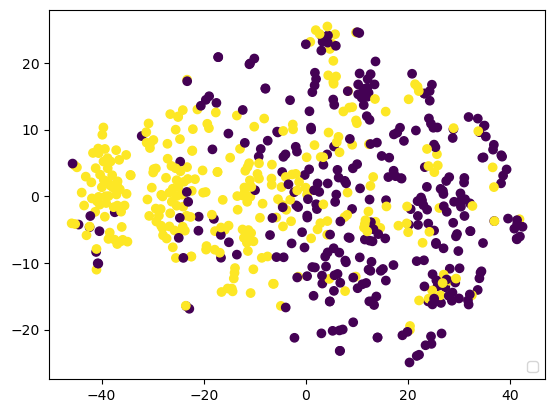

After Oversampling
Final_Ytrain
 0
0    311
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9049180327868852
Training MCC Score: 0.8102438524419773
Training F1 Score: 0.9047706204713558
Training AUC VALUE: 0.9688565314176946
Training kappa Score: 0.8096150327711829
Training Precision: 0.9198606271777003
Training Recall: 0.882943143812709
Training Sensitivity: 0.882943143812709
Training Specificity: 0.9260450160771704
Training CCR: 0.9049180327868852
Training PPV: 0.9198606271777003


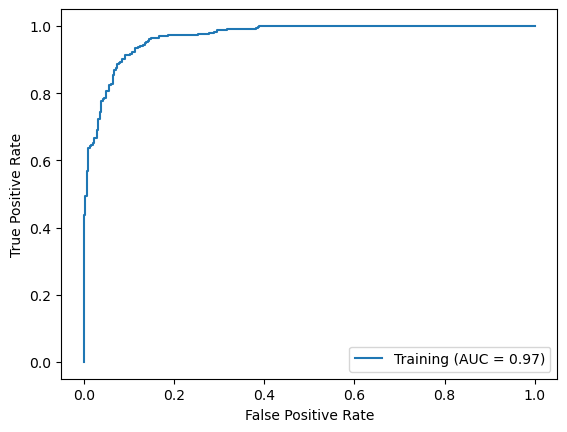

Testing Accuracy: 0.6533333333333333
Testing MCC Score: 0.3000495990744895
Testing F1 Score: 0.6470588235294117
Testing AUC VALUE: 0.7194642857142857
Testing kappa Score: 0.29729729729729726
Testing Precision: 0.65
Testing Recall: 0.5571428571428572
Testing Sensitivity: 0.5571428571428572
Testing Specificity: 0.7375
Testing CCR: 0.6533333333333333
Testing PPV: 0.65


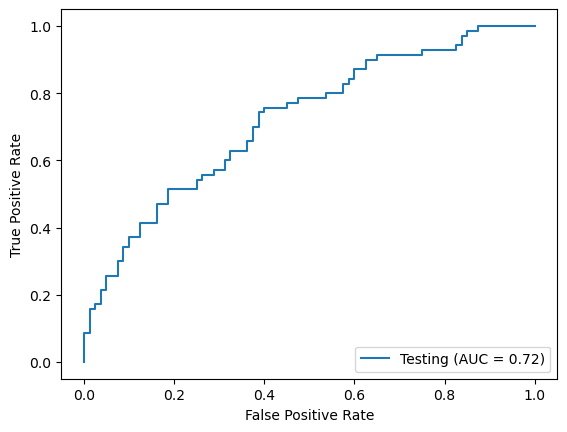

Fold # 1 Random Seed: 26
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:01:03,963:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:01:03,964:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:01:03,965:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 64
After filteration
Train shape
 (598, 64) 
Test shape
 (150, 64)
Before Oversampling
y_train_filtered
 0    317
1    281
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


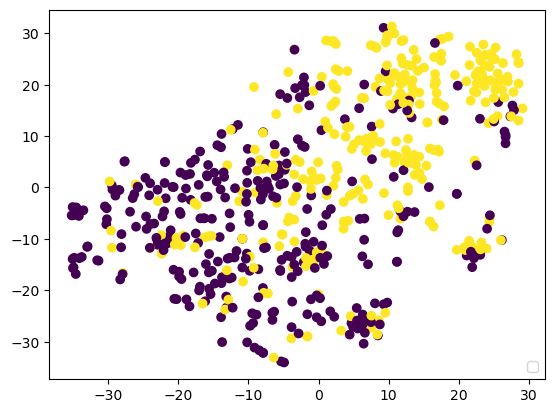

After Oversampling
Final_Ytrain
 0
0    317
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9707792207792207
Training MCC Score: 0.9415172798148956
Training F1 Score: 0.970748385462834
Training AUC VALUE: 0.9978160640621209
Training kappa Score: 0.9414973882762623
Training Precision: 0.9730639730639731
Training Recall: 0.9665551839464883
Training Sensitivity: 0.9665551839464883
Training Specificity: 0.9747634069400631
Training CCR: 0.9707792207792207
Training PPV: 0.9730639730639731


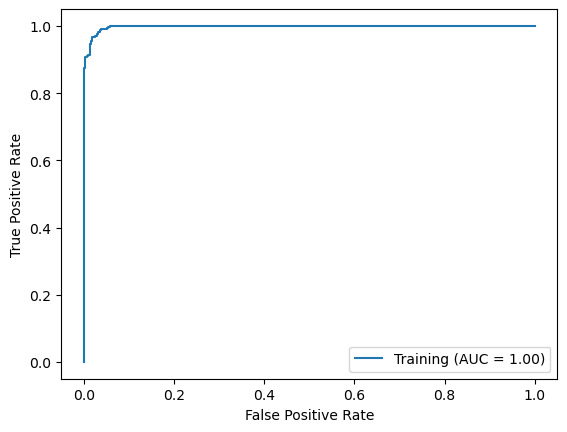

Testing Accuracy: 0.7
Testing MCC Score: 0.4097263036066289
Testing F1 Score: 0.6977296135417133
Testing AUC VALUE: 0.7900071123755334
Testing kappa Score: 0.4014896258201809
Testing Precision: 0.7540983606557377
Testing Recall: 0.6052631578947368
Testing Sensitivity: 0.6052631578947368
Testing Specificity: 0.7972972972972973
Testing CCR: 0.7
Testing PPV: 0.7540983606557377


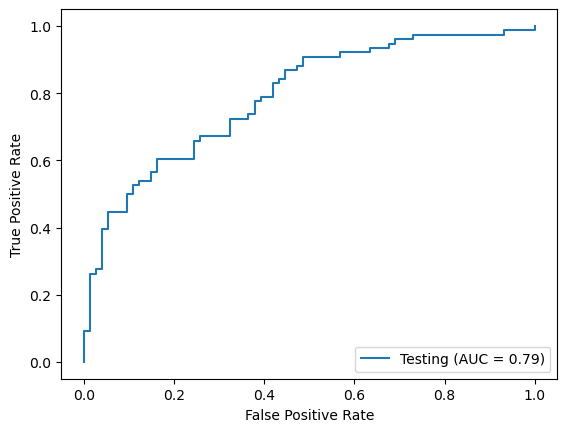

Fold # 2 Random Seed: 49
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:01:26,781:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:01:26,782:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:01:26,783:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 56
After filteration
Train shape
 (598, 56) 
Test shape
 (150, 56)
Before Oversampling
y_train_filtered
 0    311
1    287
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


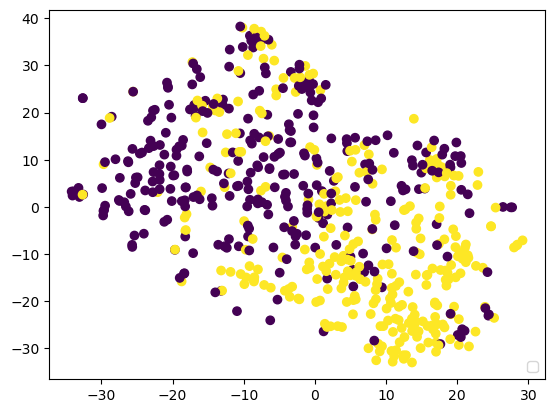

After Oversampling
Final_Ytrain
 0
0    311
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9672131147540983
Training MCC Score: 0.9344008431104754
Training F1 Score: 0.9672004215552378
Training AUC VALUE: 0.9956123842605039
Training kappa Score: 0.9344008431104754
Training Precision: 0.9665551839464883
Training Recall: 0.9665551839464883
Training Sensitivity: 0.9665551839464883
Training Specificity: 0.9678456591639871
Training CCR: 0.9672131147540983
Training PPV: 0.9665551839464883


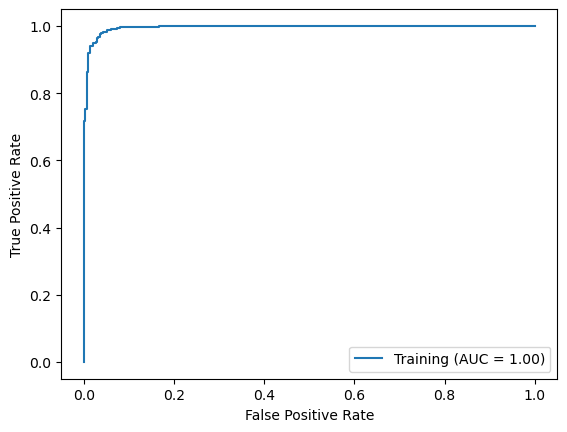

Testing Accuracy: 0.6733333333333333
Testing MCC Score: 0.3411441196105065
Testing F1 Score: 0.6690828868578632
Testing AUC VALUE: 0.7819642857142857
Testing kappa Score: 0.339622641509434
Testing Precision: 0.6666666666666666
Testing Recall: 0.6
Testing Sensitivity: 0.6
Testing Specificity: 0.7375
Testing CCR: 0.6733333333333333
Testing PPV: 0.6666666666666666


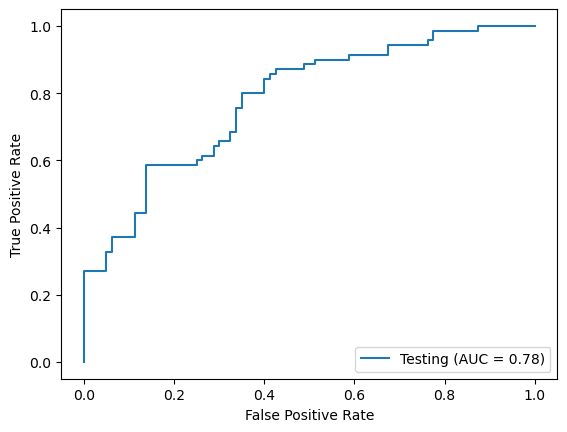

Fold # 3 Random Seed: 246
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:01:49,345:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:01:49,346:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:01:49,347:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 57
After filteration
Train shape
 (598, 57) 
Test shape
 (150, 57)
Before Oversampling
y_train_filtered
 0    308
1    290
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


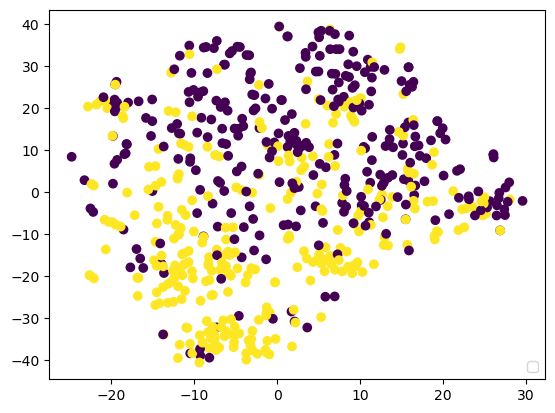

After Oversampling
Final_Ytrain
 0
0    308
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 1.0
Training MCC Score: 1.0
Training F1 Score: 1.0
Training AUC VALUE: 1.0
Training kappa Score: 1.0
Training Precision: 1.0
Training Recall: 1.0
Training Sensitivity: 1.0
Training Specificity: 1.0
Training CCR: 1.0
Training PPV: 1.0


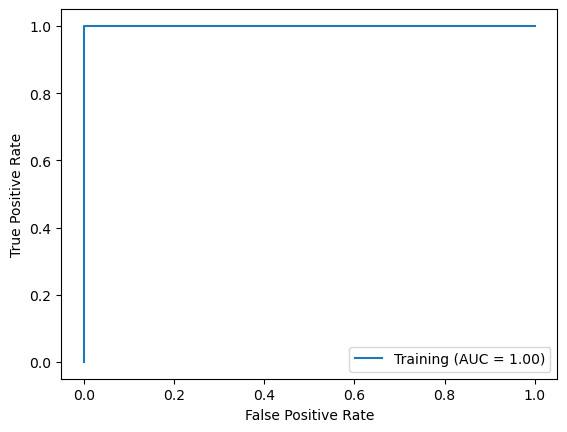

Testing Accuracy: 0.7733333333333333
Testing MCC Score: 0.5448573136296226
Testing F1 Score: 0.7718733225979604
Testing AUC VALUE: 0.8536234490199603
Testing kappa Score: 0.5440729483282676
Testing Precision: 0.7323943661971831
Testing Recall: 0.7761194029850746
Testing Sensitivity: 0.7761194029850746
Testing Specificity: 0.7710843373493976
Testing CCR: 0.7733333333333333
Testing PPV: 0.7323943661971831


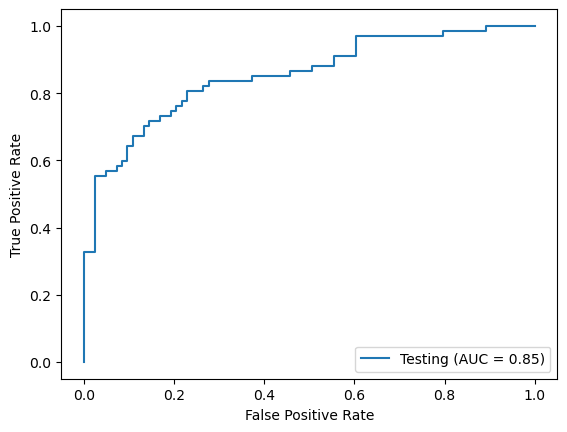

Fold # 4 Random Seed: 729
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:02:11,341:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:02:11,342:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:02:11,343:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 59
After filteration
Train shape
 (598, 59) 
Test shape
 (150, 59)
Before Oversampling
y_train_filtered
 0    308
1    290
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


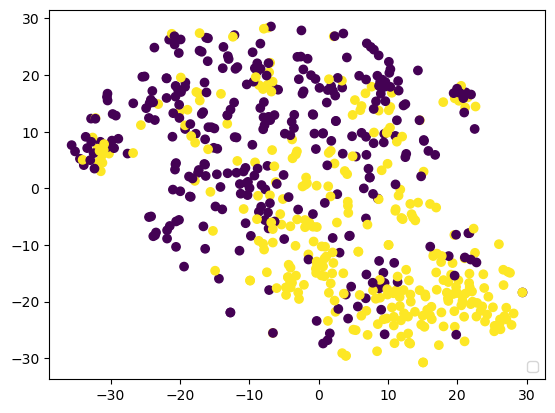

After Oversampling
Final_Ytrain
 0
0    308
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8962108731466227
Training MCC Score: 0.7931950105008695
Training F1 Score: 0.8960483645171023
Training AUC VALUE: 0.9673370108152716
Training kappa Score: 0.7922238099636509
Training Precision: 0.9154929577464789
Training Recall: 0.8695652173913043
Training Sensitivity: 0.8695652173913043
Training Specificity: 0.922077922077922
Training CCR: 0.8962108731466227
Training PPV: 0.9154929577464789


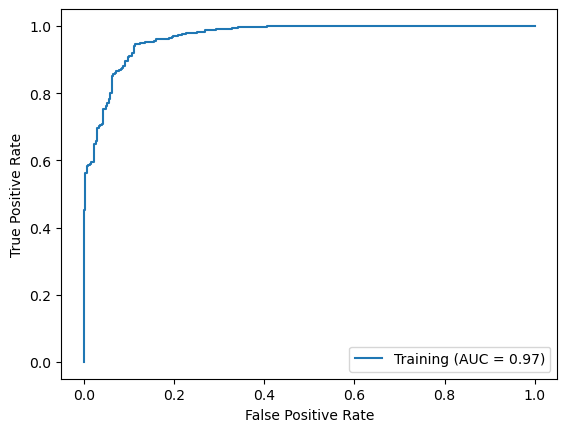

Testing Accuracy: 0.7533333333333333
Testing MCC Score: 0.4982249650076791
Testing F1 Score: 0.7462857142857142
Testing AUC VALUE: 0.8370796619313073
Testing kappa Score: 0.49444343231918386
Testing Precision: 0.7586206896551724
Testing Recall: 0.6567164179104478
Testing Sensitivity: 0.6567164179104478
Testing Specificity: 0.8313253012048193
Testing CCR: 0.7533333333333333
Testing PPV: 0.7586206896551724


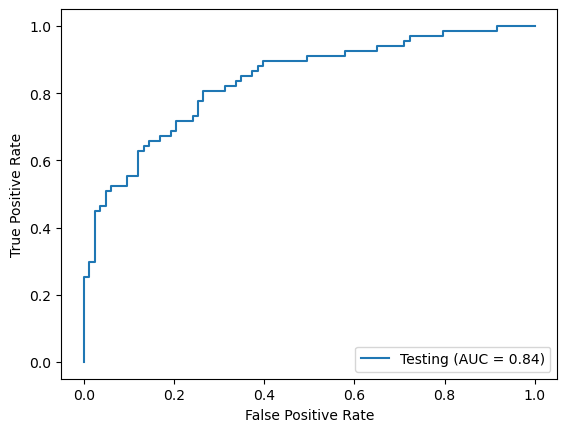

Fold # 5 Random Seed: 705
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:02:33,422:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:02:33,423:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:02:33,424:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 62
After filteration
Train shape
 (598, 62) 
Test shape
 (150, 62)
Before Oversampling
y_train_filtered
 0    309
1    289
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


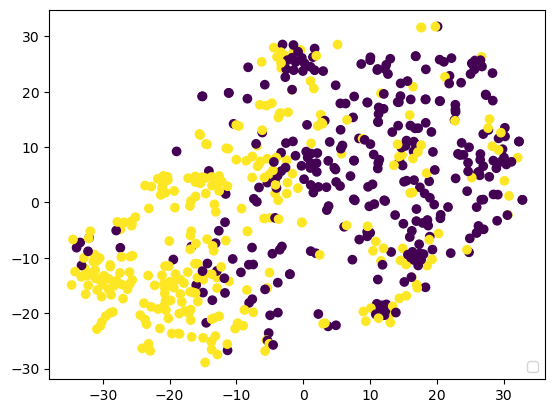

After Oversampling
Final_Ytrain
 0
0    309
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9588815789473685
Training MCC Score: 0.9177722770445248
Training F1 Score: 0.958862772162005
Training AUC VALUE: 0.9941769219945665
Training kappa Score: 0.9177275482809387
Training Precision: 0.9628378378378378
Training Recall: 0.9531772575250836
Training Sensitivity: 0.9531772575250836
Training Specificity: 0.9644012944983819
Training CCR: 0.9588815789473685
Training PPV: 0.9628378378378378


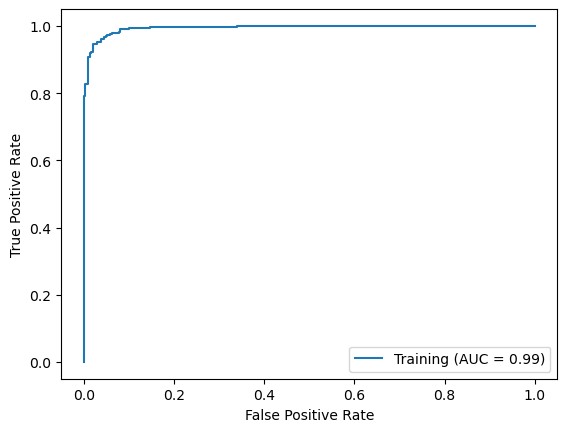

Testing Accuracy: 0.74
Testing MCC Score: 0.4732018742125148
Testing F1 Score: 0.7357604227833237
Testing AUC VALUE: 0.7892754662840745
Testing kappa Score: 0.4721169463995668
Testing Precision: 0.7301587301587301
Testing Recall: 0.6764705882352942
Testing Sensitivity: 0.6764705882352942
Testing Specificity: 0.7926829268292683
Testing CCR: 0.74
Testing PPV: 0.7301587301587301


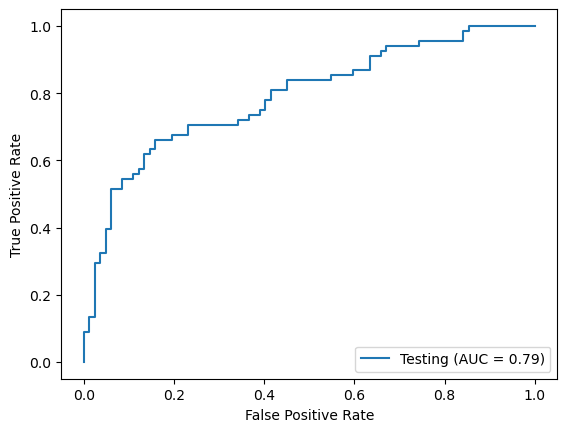

Fold # 6 Random Seed: 137
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:02:54,930:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:02:54,931:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:02:54,932:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 63
After filteration
Train shape
 (598, 63) 
Test shape
 (150, 63)
Before Oversampling
y_train_filtered
 0    312
1    286
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


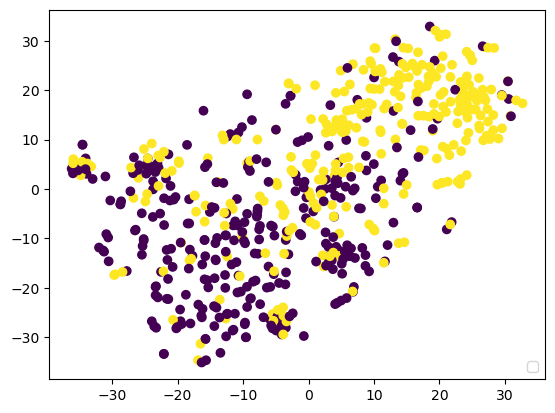

After Oversampling
Final_Ytrain
 0
0    312
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9198036006546645
Training MCC Score: 0.840651099988374
Training F1 Score: 0.9196097964400503
Training AUC VALUE: 0.9850891861761428
Training kappa Score: 0.839344262295082
Training Precision: 0.9432624113475178
Training Recall: 0.8896321070234113
Training Sensitivity: 0.8896321070234113
Training Specificity: 0.9487179487179487
Training CCR: 0.9198036006546645
Training PPV: 0.9432624113475178


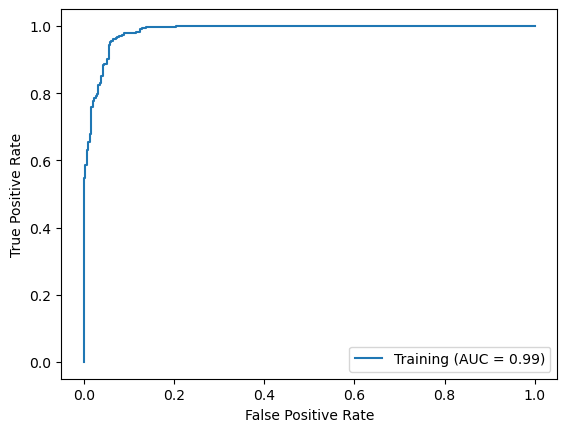

Testing Accuracy: 0.7133333333333334
Testing MCC Score: 0.42769627067085336
Testing F1 Score: 0.7064312047699239
Testing AUC VALUE: 0.7723301836334463
Testing kappa Score: 0.41881420075689313
Testing Precision: 0.75
Testing Recall: 0.5915492957746479
Testing Sensitivity: 0.5915492957746479
Testing Specificity: 0.8227848101265823
Testing CCR: 0.7133333333333334
Testing PPV: 0.75


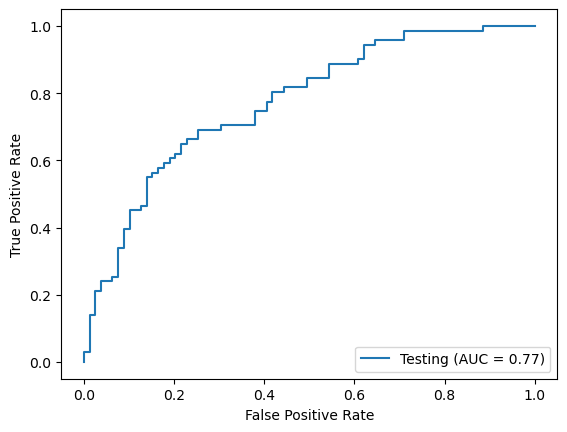

Fold # 7 Random Seed: 670
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:03:17,046:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:03:17,048:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:03:17,048:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 61
After filteration
Train shape
 (598, 61) 
Test shape
 (150, 61)
Before Oversampling
y_train_filtered
 0    326
1    272
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


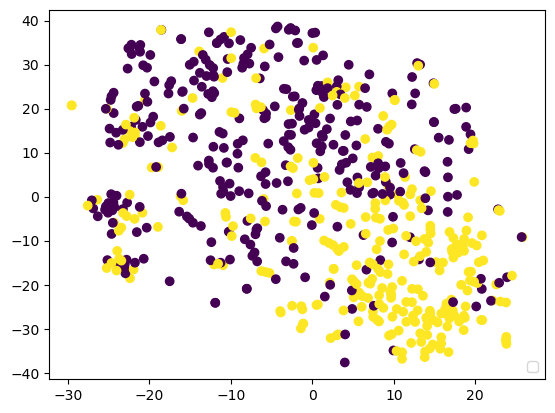

After Oversampling
Final_Ytrain
 0
0    326
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9984
Training MCC Score: 0.9967995821392409
Training F1 Score: 0.9983972263039527
Training AUC VALUE: 1.0
Training kappa Score: 0.9967944608283114
Training Precision: 0.9966666666666667
Training Recall: 1.0
Training Sensitivity: 1.0
Training Specificity: 0.9969325153374233
Training CCR: 0.9984
Training PPV: 0.9966666666666667


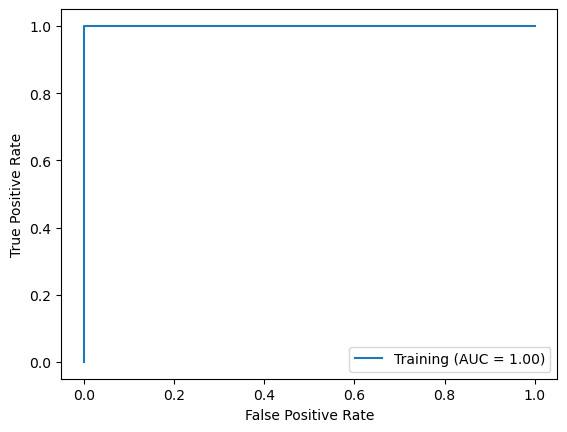

Testing Accuracy: 0.7533333333333333
Testing MCC Score: 0.5094828186944862
Testing F1 Score: 0.7519996425220072
Testing AUC VALUE: 0.7900452488687784
Testing kappa Score: 0.5057880676758681
Testing Precision: 0.8157894736842105
Testing Recall: 0.7294117647058823
Testing Sensitivity: 0.7294117647058823
Testing Specificity: 0.7846153846153846
Testing CCR: 0.7533333333333333
Testing PPV: 0.8157894736842105


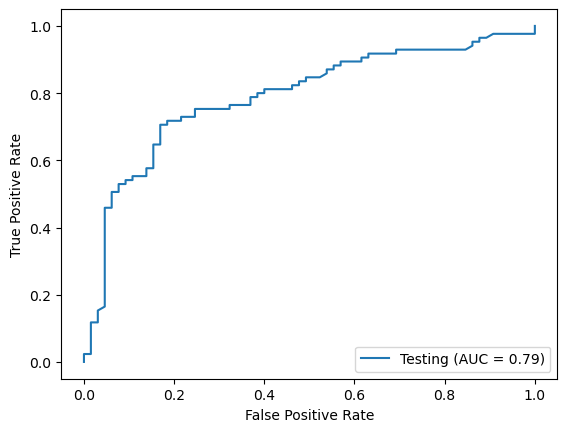

Fold # 8 Random Seed: 184
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:03:43,281:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:03:43,283:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:03:43,283:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 58
After filteration
Train shape
 (598, 58) 
Test shape
 (150, 58)
Before Oversampling
y_train_filtered
 0    312
1    286
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


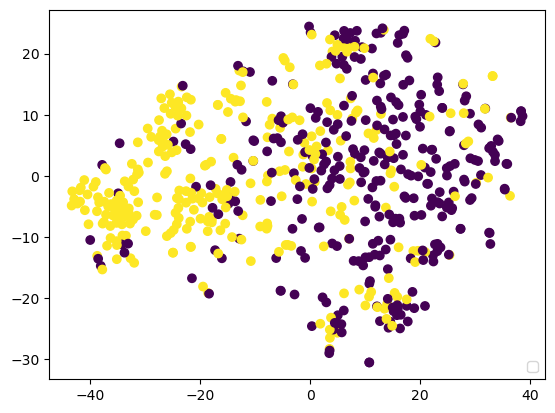

After Oversampling
Final_Ytrain
 0
0    312
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8870703764320785
Training MCC Score: 0.7755488675481677
Training F1 Score: 0.8867196001773407
Training AUC VALUE: 0.963693079495755
Training kappa Score: 0.7737073477077664
Training Precision: 0.9136690647482014
Training Recall: 0.8494983277591973
Training Sensitivity: 0.8494983277591973
Training Specificity: 0.9230769230769231
Training CCR: 0.8870703764320785
Training PPV: 0.9136690647482014


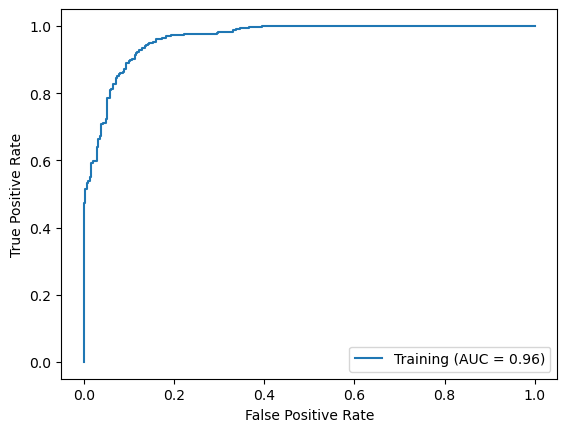

Testing Accuracy: 0.78
Testing MCC Score: 0.5582500828235945
Testing F1 Score: 0.7788104919790875
Testing AUC VALUE: 0.8456052772330184
Testing kappa Score: 0.5577988207968554
Testing Precision: 0.7794117647058824
Testing Recall: 0.7464788732394366
Testing Sensitivity: 0.7464788732394366
Testing Specificity: 0.810126582278481
Testing CCR: 0.78
Testing PPV: 0.7794117647058824


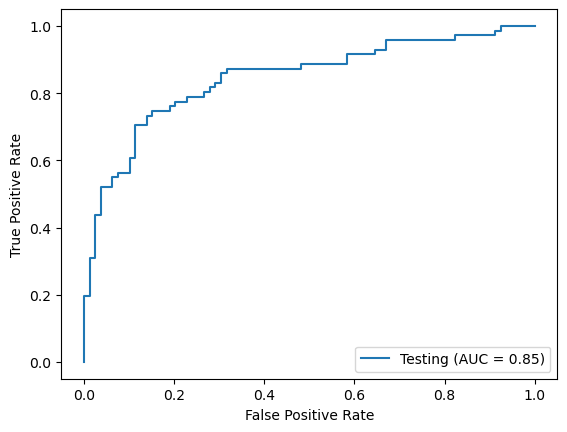

Fold # 9 Random Seed: 259
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:04:05,485:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:04:05,487:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:04:05,487:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 60
After filteration
Train shape
 (598, 60) 
Test shape
 (150, 60)
Before Oversampling
y_train_filtered
 0    307
1    291
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


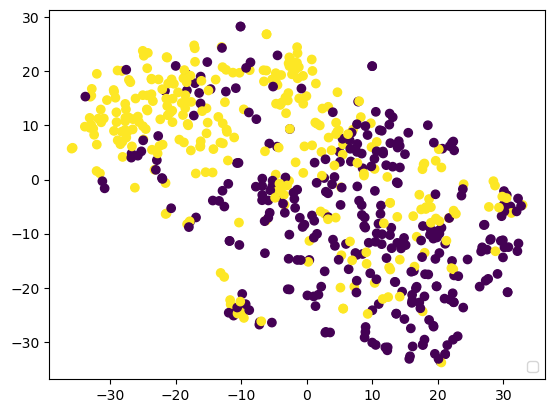

After Oversampling
Final_Ytrain
 0
0    307
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9686468646864687
Training MCC Score: 0.9372906381238879
Training F1 Score: 0.9686426807049269
Training AUC VALUE: 0.9963178020110466
Training kappa Score: 0.9372855322069349
Training Precision: 0.9666666666666667
Training Recall: 0.9698996655518395
Training Sensitivity: 0.9698996655518395
Training Specificity: 0.9674267100977199
Training CCR: 0.9686468646864687
Training PPV: 0.9666666666666667


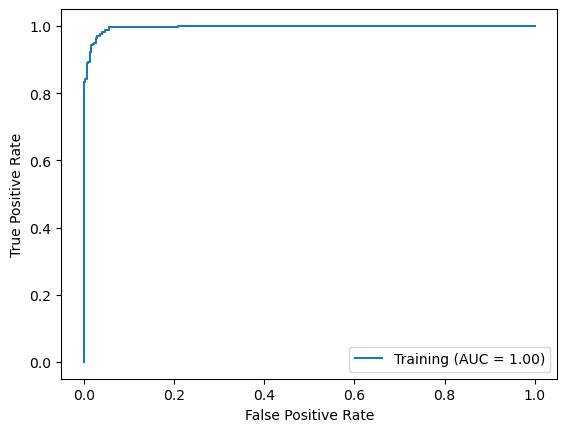

Testing Accuracy: 0.7733333333333333
Testing MCC Score: 0.537230536611122
Testing F1 Score: 0.7663123167155426
Testing AUC VALUE: 0.8474025974025975
Testing kappa Score: 0.5339912280701754
Testing Precision: 0.7758620689655172
Testing Recall: 0.6818181818181818
Testing Sensitivity: 0.6818181818181818
Testing Specificity: 0.8452380952380952
Testing CCR: 0.7733333333333333
Testing PPV: 0.7758620689655172


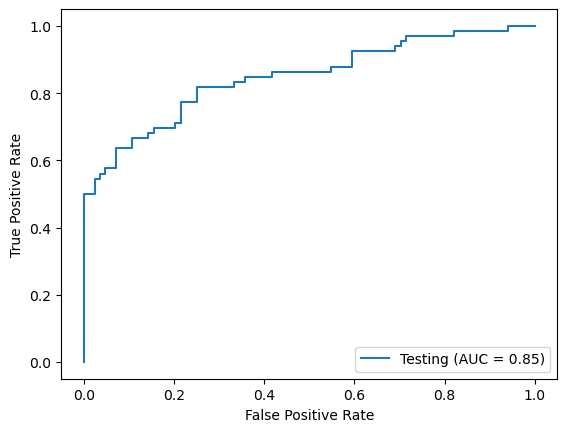

Fold # 10 Random Seed: 40
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:04:27,603:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:04:27,604:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:04:27,605:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 61
After filteration
Train shape
 (598, 61) 
Test shape
 (150, 61)
Before Oversampling
y_train_filtered
 0    317
1    281
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


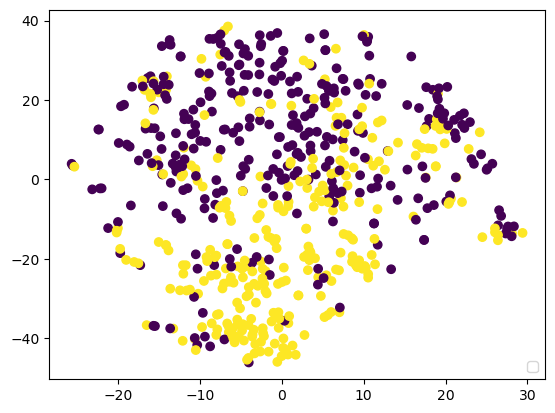

After Oversampling
Final_Ytrain
 0
0    317
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 1.0
Training MCC Score: 1.0
Training F1 Score: 1.0
Training AUC VALUE: 1.0
Training kappa Score: 1.0
Training Precision: 1.0
Training Recall: 1.0
Training Sensitivity: 1.0
Training Specificity: 1.0
Training CCR: 1.0
Training PPV: 1.0


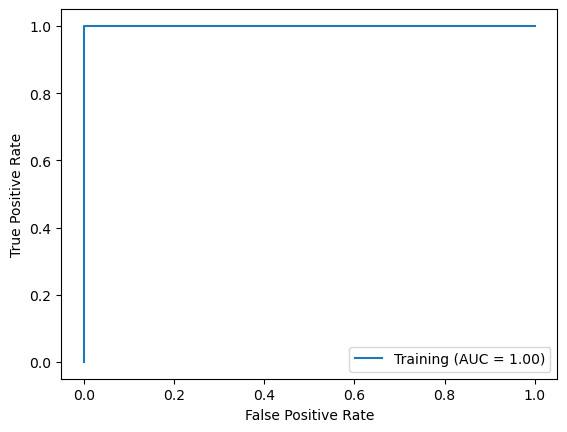

Testing Accuracy: 0.7533333333333333
Testing MCC Score: 0.5183110130430146
Testing F1 Score: 0.7514665711342976
Testing AUC VALUE: 0.856952347083926
Testing kappa Score: 0.5078914701188154
Testing Precision: 0.819672131147541
Testing Recall: 0.6578947368421053
Testing Sensitivity: 0.6578947368421053
Testing Specificity: 0.8513513513513513
Testing CCR: 0.7533333333333333
Testing PPV: 0.819672131147541


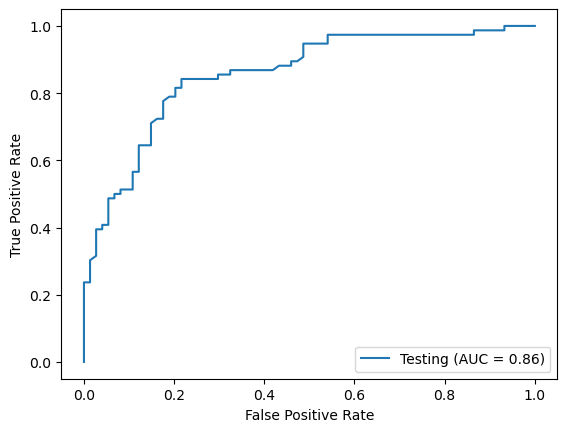

Fold # 11 Random Seed: 971
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:04:48,708:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:04:48,710:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:04:48,710:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 57
After filteration
Train shape
 (598, 57) 
Test shape
 (150, 57)
Before Oversampling
y_train_filtered
 0    318
1    280
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


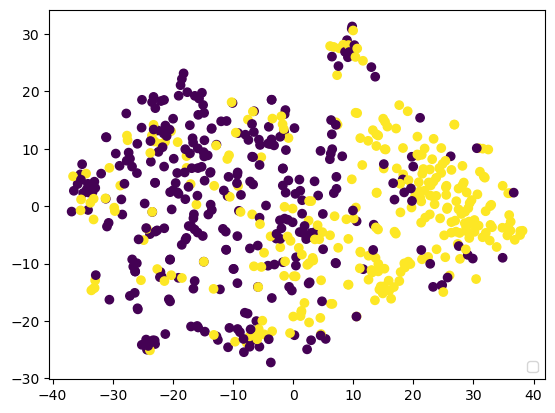

After Oversampling
Final_Ytrain
 0
0    318
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9286871961102107
Training MCC Score: 0.8577195703559822
Training F1 Score: 0.9285067206000084
Training AUC VALUE: 0.9861277634042196
Training kappa Score: 0.8570676438379243
Training Precision: 0.9442508710801394
Training Recall: 0.9063545150501672
Training Sensitivity: 0.9063545150501672
Training Specificity: 0.949685534591195
Training CCR: 0.9286871961102107
Training PPV: 0.9442508710801394


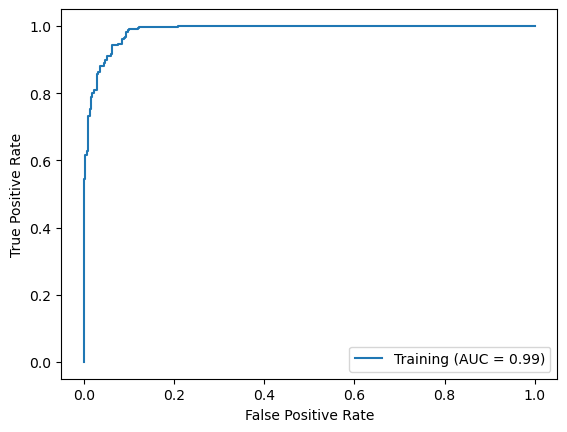

Testing Accuracy: 0.76
Testing MCC Score: 0.5345603387314551
Testing F1 Score: 0.7584541062801933
Testing AUC VALUE: 0.8496708770681374
Testing kappa Score: 0.5223774986732708
Testing Precision: 0.8360655737704918
Testing Recall: 0.6623376623376623
Testing Sensitivity: 0.6623376623376623
Testing Specificity: 0.863013698630137
Testing CCR: 0.76
Testing PPV: 0.8360655737704918


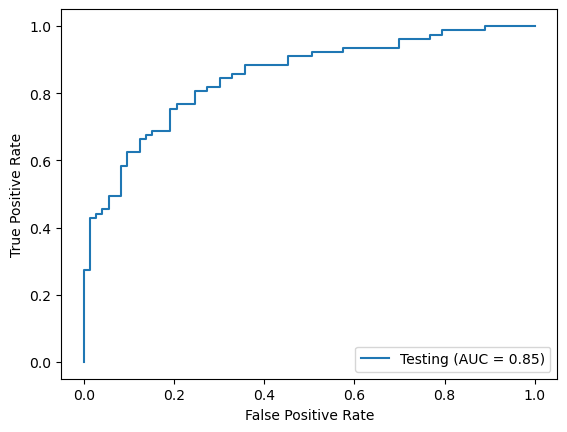

Fold # 12 Random Seed: 981
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:05:11,047:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:05:11,049:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:05:11,050:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 56
After filteration
Train shape
 (598, 56) 
Test shape
 (150, 56)
Before Oversampling
y_train_filtered
 0    311
1    287
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


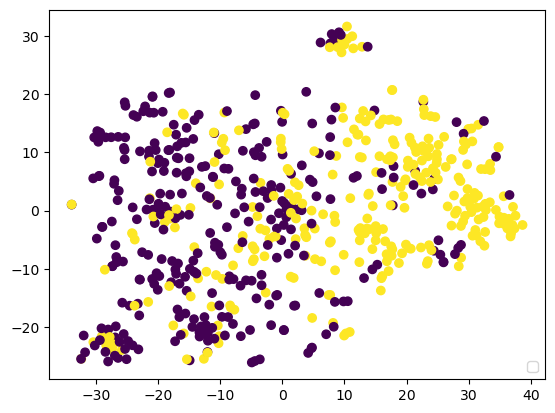

After Oversampling
Final_Ytrain
 0
0    311
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9606557377049181
Training MCC Score: 0.9217267632073161
Training F1 Score: 0.9606044949625419
Training AUC VALUE: 0.9945047263654841
Training kappa Score: 0.9212301864864574
Training Precision: 0.9757785467128027
Training Recall: 0.9431438127090301
Training Sensitivity: 0.9431438127090301
Training Specificity: 0.977491961414791
Training CCR: 0.9606557377049181
Training PPV: 0.9757785467128027


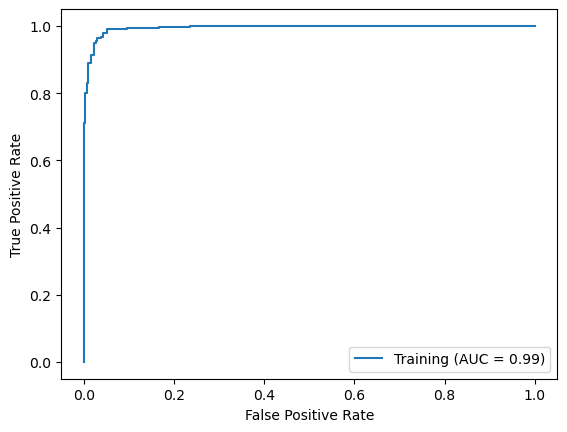

Testing Accuracy: 0.7333333333333333
Testing MCC Score: 0.4637130167514838
Testing F1 Score: 0.7285067873303168
Testing AUC VALUE: 0.7741071428571429
Testing kappa Score: 0.45945945945945943
Testing Precision: 0.75
Testing Recall: 0.6428571428571429
Testing Sensitivity: 0.6428571428571429
Testing Specificity: 0.8125
Testing CCR: 0.7333333333333333
Testing PPV: 0.75


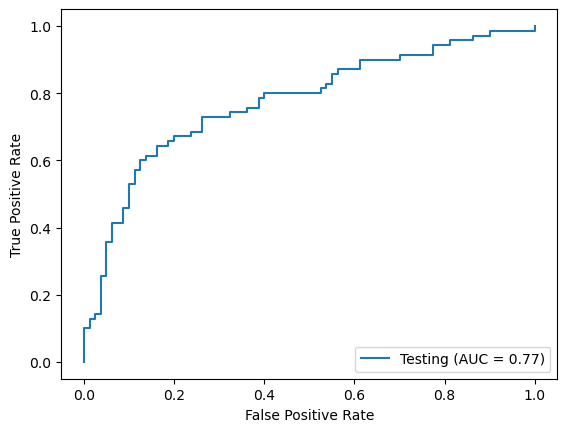

Fold # 13 Random Seed: 231
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:05:33,086:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:05:33,087:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:05:33,088:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 67
After filteration
Train shape
 (598, 67) 
Test shape
 (150, 67)
Before Oversampling
y_train_filtered
 0    311
1    287
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


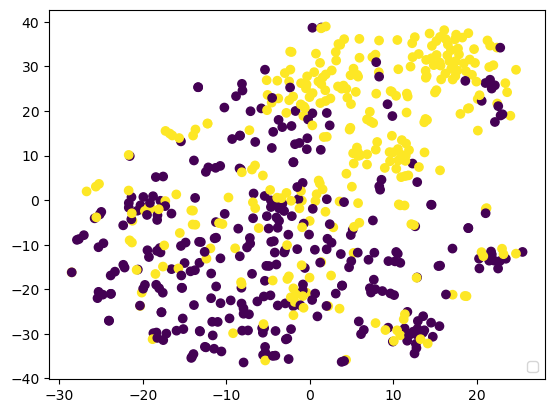

After Oversampling
Final_Ytrain
 0
0    311
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9950819672131147
Training MCC Score: 0.9901660868228185
Training F1 Score: 0.9950803674400974
Training AUC VALUE: 0.9998386905978126
Training kappa Score: 0.9901607613312544
Training Precision: 0.9933333333333333
Training Recall: 0.9966555183946488
Training Sensitivity: 0.9966555183946488
Training Specificity: 0.9935691318327974
Training CCR: 0.9950819672131147
Training PPV: 0.9933333333333333


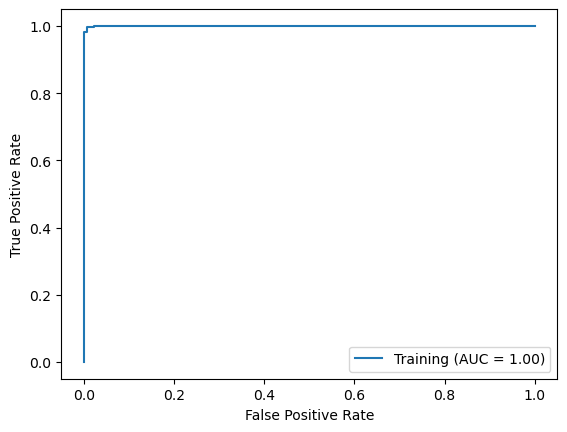

Testing Accuracy: 0.7866666666666666
Testing MCC Score: 0.5716838034938632
Testing F1 Score: 0.7835497835497836
Testing AUC VALUE: 0.8567857142857143
Testing kappa Score: 0.5683453237410072
Testing Precision: 0.8064516129032258
Testing Recall: 0.7142857142857143
Testing Sensitivity: 0.7142857142857143
Testing Specificity: 0.85
Testing CCR: 0.7866666666666666
Testing PPV: 0.8064516129032258


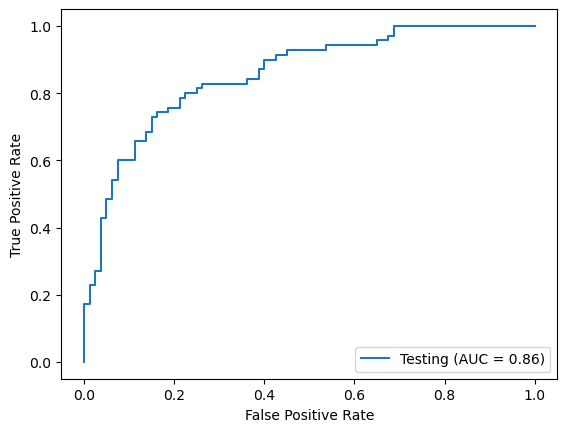

Fold # 14 Random Seed: 142
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:05:57,125:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:05:57,126:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:05:57,127:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 55
After filteration
Train shape
 (598, 55) 
Test shape
 (150, 55)
Before Oversampling
y_train_filtered
 0    312
1    286
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


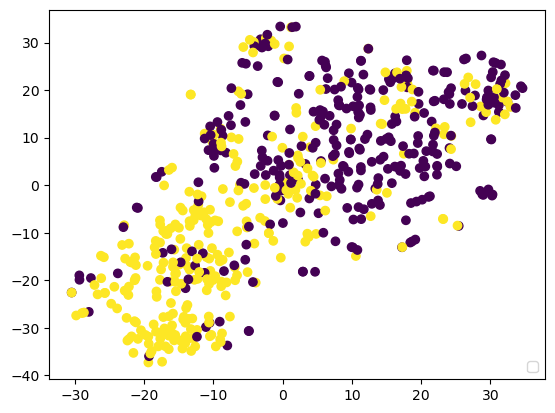

After Oversampling
Final_Ytrain
 0
0    312
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9983633387888707
Training MCC Score: 0.9967307671694611
Training F1 Score: 0.9983627072408
Training AUC VALUE: 1.0
Training kappa Score: 0.9967254232564621
Training Precision: 0.9966666666666667
Training Recall: 1.0
Training Sensitivity: 1.0
Training Specificity: 0.9967948717948718
Training CCR: 0.9983633387888707
Training PPV: 0.9966666666666667


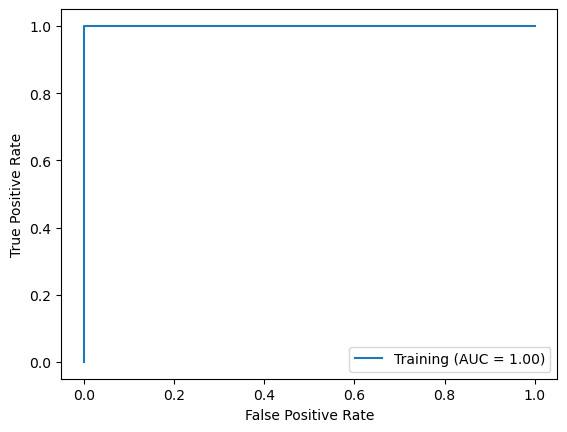

Testing Accuracy: 0.76
Testing MCC Score: 0.518247190398836
Testing F1 Score: 0.7578909612625538
Testing AUC VALUE: 0.7994294883223391
Testing kappa Score: 0.5165622202327664
Testing Precision: 0.7692307692307693
Testing Recall: 0.704225352112676
Testing Sensitivity: 0.704225352112676
Testing Specificity: 0.810126582278481
Testing CCR: 0.76
Testing PPV: 0.7692307692307693


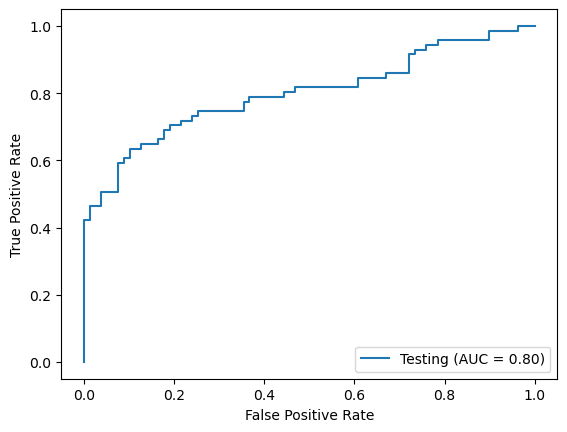

Fold # 15 Random Seed: 271
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:06:21,899:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:06:21,901:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:06:21,901:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 59
After filteration
Train shape
 (598, 59) 
Test shape
 (150, 59)
Before Oversampling
y_train_filtered
 0    312
1    286
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


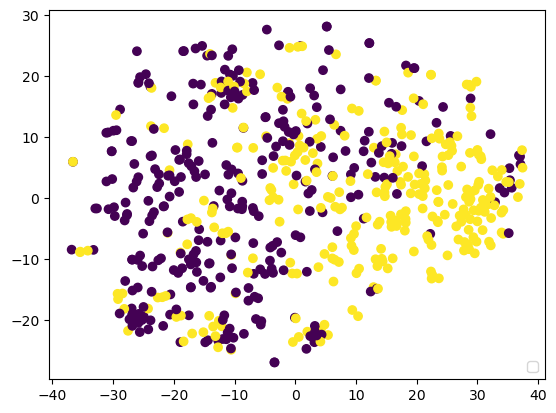

After Oversampling
Final_Ytrain
 0
0    312
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9148936170212766
Training MCC Score: 0.8300372308273137
Training F1 Score: 0.9147728492027726
Training AUC VALUE: 0.9817232655861418
Training kappa Score: 0.8295914098452098
Training Precision: 0.9273356401384083
Training Recall: 0.8963210702341137
Training Sensitivity: 0.8963210702341137
Training Specificity: 0.9326923076923077
Training CCR: 0.9148936170212766
Training PPV: 0.9273356401384083


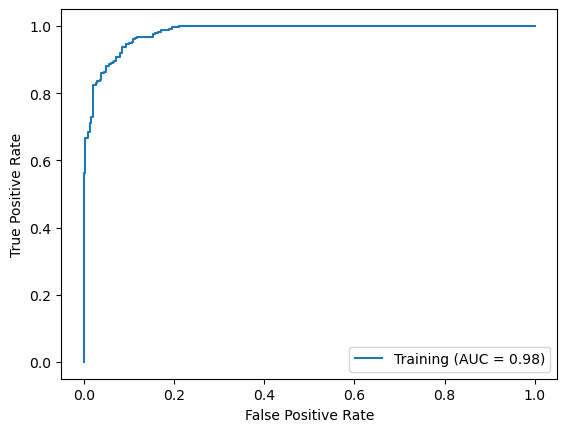

Testing Accuracy: 0.74
Testing MCC Score: 0.4781873251647261
Testing F1 Score: 0.7390606182256122
Testing AUC VALUE: 0.8300944909966125
Testing kappa Score: 0.47814451382694023
Testing Precision: 0.7285714285714285
Testing Recall: 0.7183098591549296
Testing Sensitivity: 0.7183098591549296
Testing Specificity: 0.759493670886076
Testing CCR: 0.74
Testing PPV: 0.7285714285714285


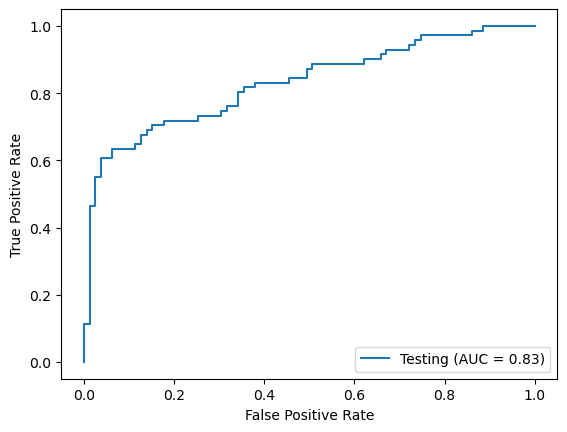

Fold # 16 Random Seed: 356
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:06:44,767:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:06:44,768:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:06:44,769:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 62
After filteration
Train shape
 (598, 62) 
Test shape
 (150, 62)
Before Oversampling
y_train_filtered
 0    317
1    281
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


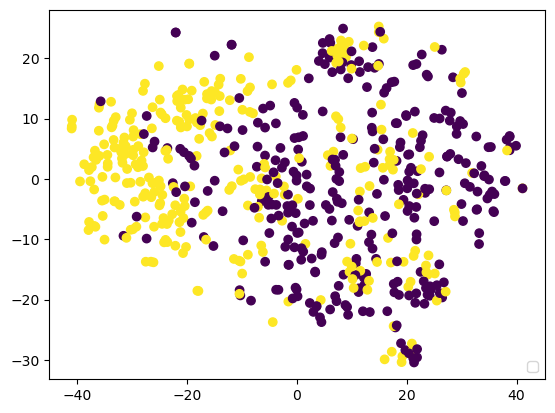

After Oversampling
Final_Ytrain
 0
0    317
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9935064935064936
Training MCC Score: 0.9870018885243135
Training F1 Score: 0.9935009442621567
Training AUC VALUE: 0.9998944958484117
Training kappa Score: 0.9870018885243135
Training Precision: 0.9933110367892977
Training Recall: 0.9933110367892977
Training Sensitivity: 0.9933110367892977
Training Specificity: 0.9936908517350158
Training CCR: 0.9935064935064936
Training PPV: 0.9933110367892977


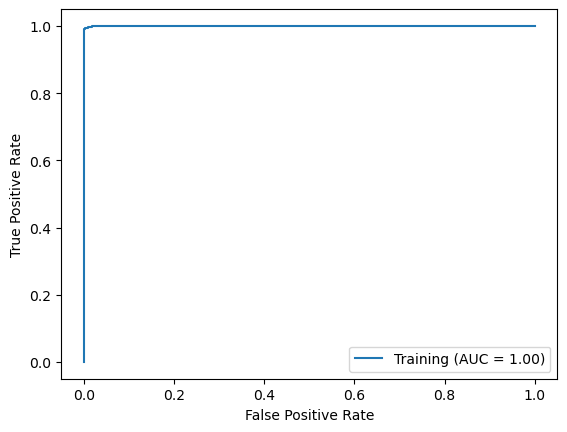

Testing Accuracy: 0.72
Testing MCC Score: 0.4448538204614321
Testing F1 Score: 0.7192012836512747
Testing AUC VALUE: 0.8049431009957325
Testing kappa Score: 0.4408945686900959
Testing Precision: 0.7575757575757576
Testing Recall: 0.6578947368421053
Testing Sensitivity: 0.6578947368421053
Testing Specificity: 0.7837837837837838
Testing CCR: 0.72
Testing PPV: 0.7575757575757576


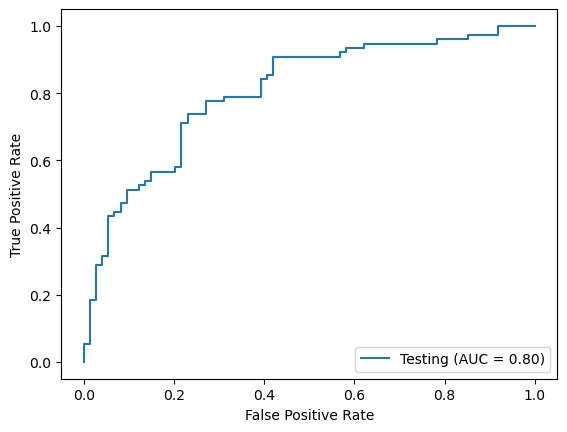

Fold # 17 Random Seed: 471
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:07:07,389:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:07:07,390:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:07:07,391:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 56
After filteration
Train shape
 (598, 56) 
Test shape
 (150, 56)
Before Oversampling
y_train_filtered
 0    325
1    273
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


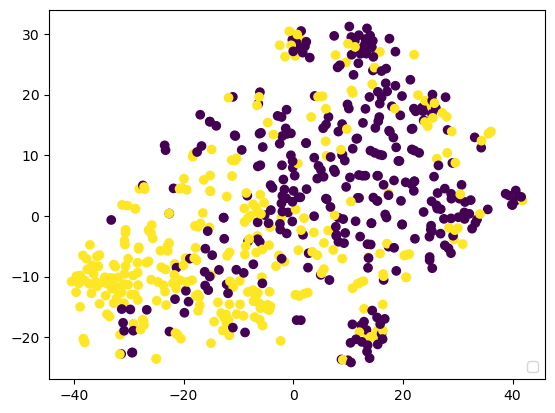

After Oversampling
Final_Ytrain
 0
0    325
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9727564102564102
Training MCC Score: 0.9454156315688659
Training F1 Score: 0.9727053084161206
Training AUC VALUE: 0.9976125546694109
Training kappa Score: 0.9454107572919455
Training Precision: 0.9731543624161074
Training Recall: 0.9698996655518395
Training Sensitivity: 0.9698996655518395
Training Specificity: 0.9753846153846154
Training CCR: 0.9727564102564102
Training PPV: 0.9731543624161074


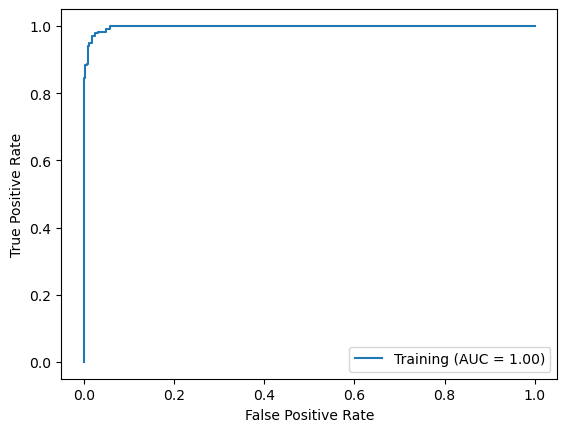

Testing Accuracy: 0.74
Testing MCC Score: 0.499235163991894
Testing F1 Score: 0.7399884439308414
Testing AUC VALUE: 0.8304473304473304
Testing kappa Score: 0.48657187993680884
Testing Precision: 0.835820895522388
Testing Recall: 0.6666666666666666
Testing Sensitivity: 0.6666666666666666
Testing Specificity: 0.8333333333333334
Testing CCR: 0.74
Testing PPV: 0.835820895522388


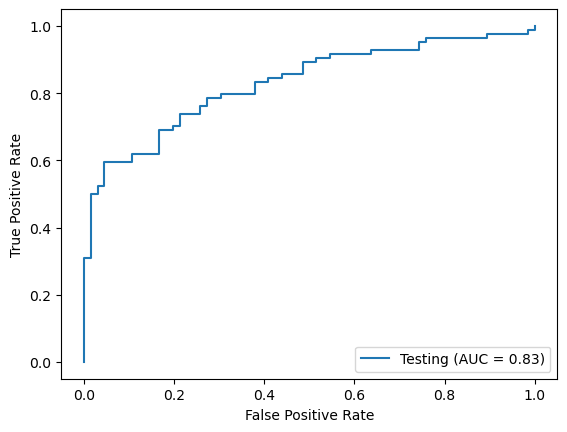

Fold # 18 Random Seed: 10
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:07:29,959:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:07:29,960:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:07:29,961:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 70
After filteration
Train shape
 (598, 70) 
Test shape
 (150, 70)
Before Oversampling
y_train_filtered
 0    314
1    284
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


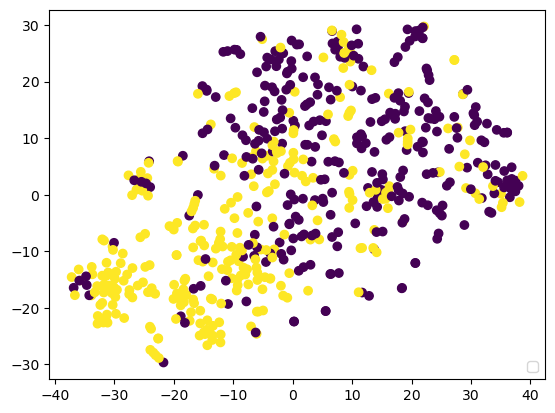

After Oversampling
Final_Ytrain
 0
0    314
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9575856443719413
Training MCC Score: 0.9151535247824736
Training F1 Score: 0.9575665601703941
Training AUC VALUE: 0.9933855952964233
Training kappa Score: 0.9151340241317983
Training Precision: 0.9534883720930233
Training Recall: 0.959866220735786
Training Sensitivity: 0.959866220735786
Training Specificity: 0.9554140127388535
Training CCR: 0.9575856443719413
Training PPV: 0.9534883720930233


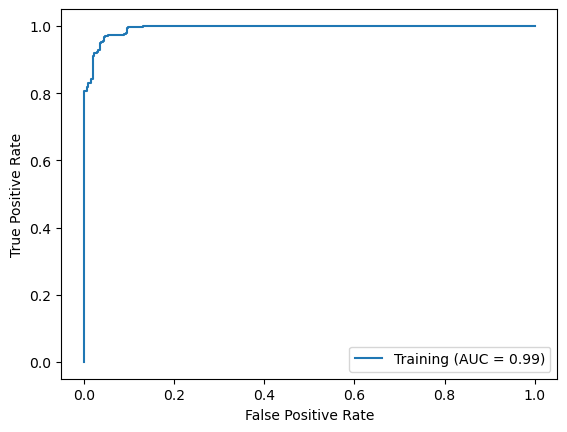

Testing Accuracy: 0.7133333333333334
Testing MCC Score: 0.42609241558990435
Testing F1 Score: 0.7130144605116797
Testing AUC VALUE: 0.8011030065824586
Testing kappa Score: 0.42605445808862785
Testing Precision: 0.7083333333333334
Testing Recall: 0.6986301369863014
Testing Sensitivity: 0.6986301369863014
Testing Specificity: 0.7272727272727273
Testing CCR: 0.7133333333333334
Testing PPV: 0.7083333333333334


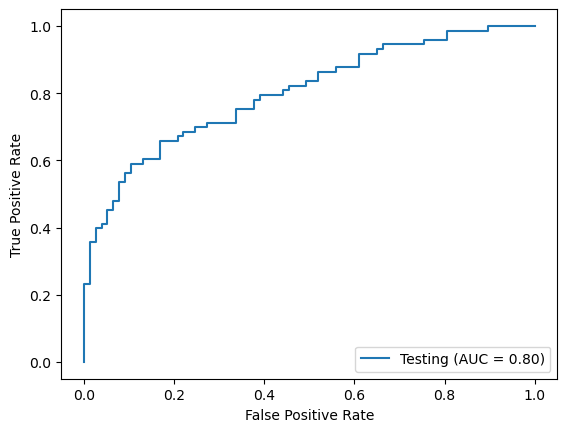

Fold # 19 Random Seed: 46
Before filteration
Train shape
 (598, 3200) 
Test shape
 (150, 3200)


2024-11-04 22:07:53,914:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:07:53,916:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:07:53,916:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 64
After filteration
Train shape
 (598, 64) 
Test shape
 (150, 64)
Before Oversampling
y_train_filtered
 0    320
1    278
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


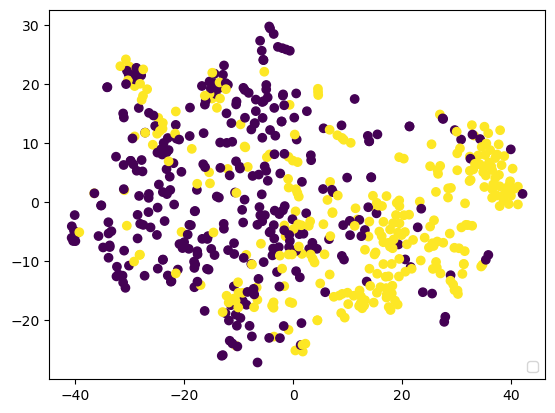

After Oversampling
Final_Ytrain
 0
0    320
1    299
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 1.0
Training MCC Score: 1.0
Training F1 Score: 1.0
Training AUC VALUE: 1.0
Training kappa Score: 1.0
Training Precision: 1.0
Training Recall: 1.0
Training Sensitivity: 1.0
Training Specificity: 1.0
Training CCR: 1.0
Training PPV: 1.0


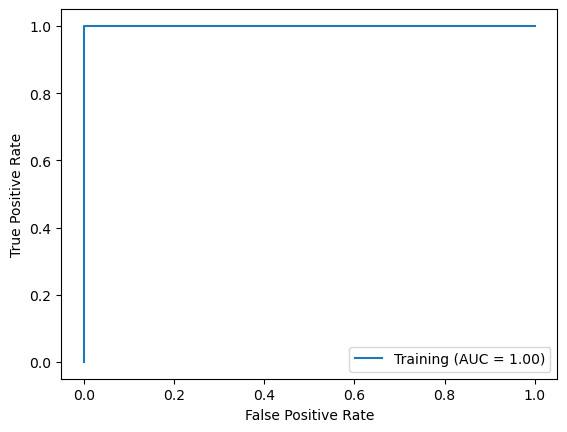

Testing Accuracy: 0.7466666666666667
Testing MCC Score: 0.5091412179208701
Testing F1 Score: 0.7459440185416295
Testing AUC VALUE: 0.7983597789267249
Testing kappa Score: 0.4976203067160233
Testing Precision: 0.8253968253968254
Testing Recall: 0.6582278481012658
Testing Sensitivity: 0.6582278481012658
Testing Specificity: 0.8450704225352113
Testing CCR: 0.7466666666666667
Testing PPV: 0.8253968253968254


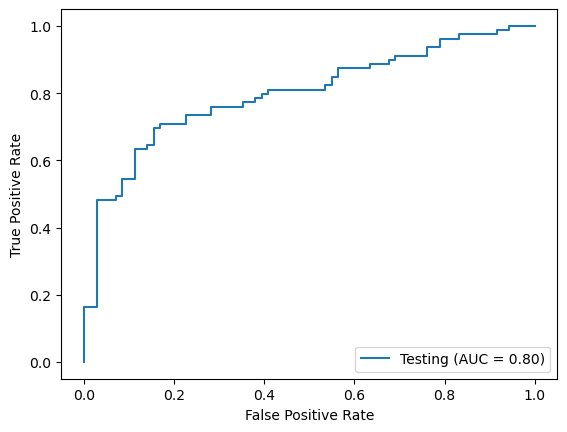

In [26]:
Train_Fold_outs=[]
Test_Fold_outs=[]
Best_params=[]
features = []
models=[]

#this chunk runs 20 iterations of the 5-Cross Validation of the pre-defined grid for the model
for i in range(20):
    #print('Fold #',i)   
    seed = random.randint(0, 1000)
    print('Fold #', i, "Random Seed:", seed)
    
    # Split Data
    X_train, X_test,y_train,y_test = train_test_split(Train,Train["status"] ,test_size=0.20, shuffle = True, random_state=seed)
    
    #Drop smiles,status from training,testing data
    x_train = X_train.drop(['status','smiles'], axis=1)
    x_test = X_test.drop(['status','smiles'], axis=1)

    #Feature selection
    x_train_filtered,x_test_filtered,y_train_filtered,y_test_filtered,selected_features = Boruta_Filteration(x_train,y_train,x_test,y_test)
    features.append(selected_features)
    
    y_train_filtered = pd.Series(y_train_filtered)

    print('Before Oversampling\ny_train_filtered\n',y_train_filtered.value_counts())
    #Oversampling
    Final_Xtrain,Final_Ytrain = Smote(x_train_filtered,y_train_filtered,0.5)
    print('After Oversampling\nFinal_Ytrain\n',Final_Ytrain.value_counts())
    
    Final_Ytrain=Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype = np.float64)
    x_test_filtered = pd.DataFrame(x_test_filtered, dtype = np.float64)
    
    #Hyperparameter Tuning
    Parameters = HPTing_Model(Final_Xtrain,Final_Ytrain)
    
    #save best parameters
    Best_params.append(Parameters.best_estimator_.get_params())
    
    #build the tuned model
    #edit the parameters here according to your defined parameter space and model's grid
    rf = RandomForestClassifier(max_features=Parameters.best_estimator_.get_params()['max_features'],
                        max_depth=Parameters.best_estimator_.get_params()['max_depth'],
                        min_samples_split=Parameters.best_estimator_.get_params()['min_samples_split'],
                        min_samples_leaf=Parameters.best_estimator_.get_params()['min_samples_leaf'],
                        bootstrap=Parameters.best_estimator_.get_params()['bootstrap'],
                        n_estimators=Parameters.best_estimator_.get_params()['n_estimators'])

    
    #fit the built model
    rf.fit(Final_Xtrain,Final_Ytrain)
    models.append(rf)

    #Training Predictions for the model
    y_train_pred=rf.predict(Final_Xtrain)
    y_train_prob=rf.predict_proba(Final_Xtrain)

    #Save training metrics
    Train_Fold_outs.append(Scoring_metrices(y_train_pred,y_train_prob[:,1],Final_Ytrain,'Training'))

    #Testing Predictions for the model
    y_test_pred=rf.predict(x_test_filtered) 
    y_test_prob=rf.predict_proba(x_test_filtered)

    #Save testing metrics
    Test_Fold_outs.append(Scoring_metrices(y_test_pred,y_test_prob[:,1],y_test_filtered,'Testing'))

In [27]:
#Analyse the testing metrics sorted by descending Testing Accuracy
pd.DataFrame.from_dict(Test_Fold_outs).sort_values(by=['Testing kappa Score:'],ascending = False)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
13,0.786667,0.571684,0.783550,0.856786,0.568345,0.806452,0.714286,0.714286,0.850000,0.786667,0.806452
8,0.780000,0.558250,0.778810,0.845605,0.557799,0.779412,0.746479,0.746479,0.810127,0.780000,0.779412
3,0.773333,0.544857,0.771873,0.853623,0.544073,0.732394,0.776119,0.776119,0.771084,0.773333,0.732394
9,0.773333,0.537231,0.766312,0.847403,0.533991,0.775862,0.681818,0.681818,0.845238,0.773333,0.775862
11,0.760000,0.534560,0.758454,0.849671,0.522377,0.836066,0.662338,0.662338,0.863014,0.760000,0.836066
14,0.760000,0.518247,0.757891,0.799429,0.516562,0.769231,0.704225,0.704225,0.810127,0.760000,0.769231
10,0.753333,0.518311,0.751467,0.856952,0.507891,0.819672,0.657895,0.657895,0.851351,0.753333,0.819672
7,0.753333,0.509483,0.752000,0.790045,0.505788,0.815789,0.729412,0.729412,0.784615,0.753333,0.815789
19,0.746667,0.509141,0.745944,0.798360,0.497620,0.825397,0.658228,0.658228,0.845070,0.746667,0.825397
4,0.753333,0.498225,0.746286,0.837080,0.494443,0.758621,0.656716,0.656716,0.831325,0.753333,0.758621


In [28]:
#View the best parameters
pd.DataFrame.from_dict(Best_params)

,bootstrap,ccp_alpha,class_weight,criterion,max_depth,max_features,max_leaf_nodes,max_samples,min_impurity_decrease,min_samples_leaf,min_samples_split,min_weight_fraction_leaf,n_estimators,n_jobs,oob_score,random_state,verbose,warm_start
0,True,0.0,None,gini,20.0,0.5,None,None,0.0,12,3,0.0,78,None,False,None,0,False
1,True,0.0,None,gini,60.0,sqrt,None,None,0.0,2,12,0.0,100,None,False,None,0,False
2,True,0.0,None,gini,80.0,0.5,None,None,0.0,2,18,0.0,45,None,False,None,0,False
3,False,0.0,None,gini,50.0,sqrt,None,None,0.0,3,9,0.0,89,None,False,None,0,False
4,True,0.0,None,gini,30.0,log2,None,None,0.0,6,26,0.0,100,None,False,None,0,False
5,True,0.0,None,gini,60.0,0.5,None,None,0.0,4,15,0.0,67,None,False,None,0,False
6,True,0.0,None,gini,70.0,log2,None,None,0.0,5,17,0.0,100,None,False,None,0,False
7,False,0.0,None,gini,10.0,sqrt,None,None,0.0,3,3,0.0,12,None,False,None,0,False
8,True,0.0,None,gini,10.0,sqrt,None,None,0.0,11,26,0.0,100,None,False,None,0,False
9,True,0.0,None,gini,110.0,log2,None,None,0.0,3,8,0.0,34,None,False,None,0,False


In [29]:
#View length of the features selected for the top performing/most stable (selected) model (1st here)
len(features[13])

67

In [30]:
#Save the feature names
pd.DataFrame(features[13]).to_csv('AID_1194_features.csv',index=False)

In [31]:
#save the best parameters of the chosen model
with open('AID_1194_best_params_RF.csv', 'w') as f:  # You will need 'wb' mode in Python 2.x
    w = csv.DictWriter(f, Best_params[13].keys())
    w.writeheader()
    w.writerow(Best_params[13])

In [ ]:
"""
#Randomly split the data into testing and validation for each fold
def Test_valid_split(Set3,frac,seed):
    Fraction=frac
    Test=Set3[Set3['status']==1].sample(frac = Fraction,random_state=1).append(Set3[Set3['status']==0].sample(frac = Fraction,random_state=seed))
    Valid_index=[item for item in list(Set3.index) if item not in list(Test.index)]
    Valid=Set3.T[Valid_index].T
    print('Test set size:',len(Test),'\nValid set size:',len(Valid))
    return Test,Valid
"""

In [32]:
def Test_valid_split(Set3, frac, seed):
    Fraction = frac
    Test_1 = Set3[Set3['status'] == 1].sample(frac=Fraction, random_state=1)
    Test_0 = Set3[Set3['status'] == 0].sample(frac=Fraction, random_state=seed)
    
    # 使用 pd.concat 代替 append
    Test = pd.concat([Test_1, Test_0])
    
    Valid_index = [item for item in list(Set3.index) if item not in list(Test.index)]
    Valid = Set3.T[Valid_index].T
    print('Test set size:', len(Test), '\nValid set size:', len(Valid))
    
    return Test, Valid

In [34]:
import pandas as pd

# 读取 CSV 文件
df = pd.read_csv('AID_1194_features.csv')

# 假设第一列名为 'Features'
f_list = df['Features'].tolist()

# 输出 f_list 确认结果
print(f_list)

['A2_123', 'A5_93', 'B2_12', 'B2_38', 'B2_40', 'B2_102', 'B3_9', 'B3_19', 'B3_20', 'B3_22', 'B3_33', 'B3_41', 'B3_85', 'B4_81', 'B4_117', 'B5_22', 'C1_21', 'C1_29', 'C1_40', 'C1_41', 'C1_43', 'C1_68', 'C1_76', 'C1_95', 'C1_104', 'C1_111', 'C1_119', 'C2_33', 'C2_76', 'C3_36', 'C3_69', 'C4_12', 'C4_35', 'D1_8', 'D1_105', 'D1_120', 'D4_8', 'D4_34', 'D4_87', 'D4_114', 'D4_126', 'E1_72', 'E1_77', 'E1_96', 'E2_45', 'E2_63', 'E2_94', 'E3_96', 'E4_6', 'E4_15', 'E4_17', 'E4_22', 'E4_37', 'E4_40', 'E4_61', 'E4_90', 'E4_102', 'E4_111', 'E4_113', 'E4_117', 'E4_120', 'E4_122', 'E4_125', 'E5_3', 'E5_13', 'E5_87', 'E5_110']


In [35]:
''' 
#f_list=features[1] #feature list of the selected (hyperparameter tuned) model
Train_Fold_outs_1=[]
Test_Fold_outs_1=[]
models_1=[]

# 用于存储训练和测试集的预测结果和标签
total_metrics= []


Parameters = pd.DataFrame.from_dict(Best_params).iloc[3].to_dict()
print(Parameters)
for i in range(20):
    print('Fold #',i)
    
    #Train-test split randomly
    Trn,Tst = Test_valid_split(Data,0.9,i)
    Train_y, Test_y = Trn['status'],Tst['status']

    #Use selected feature list
    Train_x = Trn[f_list]
    Test_x = Tst[f_list]
    print(Trn[f_list].shape)
    
    x_train_filtered = Train_x.values
    x_test_filtered = Test_x.values
    y_train_filtered = Train_y.values.ravel()
    y_test_filtered = Test_y.values.ravel()

    print(Train_y.value_counts())
    #Upsampling
    Final_Xtrain,Final_Ytrain = Smote(Train_x,Train_y,0.5)
    print(Final_Ytrain.value_counts())
    
    Final_Ytrain=Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype = np.float64)
    x_test_filtered = pd.DataFrame(x_test_filtered, dtype = np.float64)

    #Use the best parameters from the chosen model here

    rf = RandomForestClassifier(max_features=Parameters['max_features'],
                        max_depth=Parameters['max_depth'],
                        min_samples_split=Parameters['min_samples_split'],
                        min_samples_leaf=Parameters['min_samples_leaf'],
                        bootstrap=Parameters['bootstrap'],
                        n_estimators=Parameters['n_estimators'])


    
    #Fit the model
    rf.fit(Final_Xtrain,Final_Ytrain)
    models_1.append(rf)
    
    #Training prediction and saving the metrics
    y_train_pred=rf.predict(Final_Xtrain)
    y_train_prob=rf.predict_proba(Final_Xtrain)
    Train_Fold_outs_1.append(Scoring_metrices(y_train_pred,y_train_prob[:,1],Final_Ytrain.astype('int'),'Training'))

    #Testing prediction and saving the metrics
    y_test_pred=rf.predict(x_test_filtered) 
    y_test_prob=rf.predict_proba(x_test_filtered)
    Test_Fold_outs_1.append(Scoring_metrices(y_test_pred,y_test_prob[:,1],y_test_filtered.astype('int'),'Testing'))
'''
'''
    all_predictions = []
    all_probabilities = []
    all_labels = []
    # 拼接训练集和测试集的预测结果和真实标签
    all_predictions.extend(y_train_pred)
    all_probabilities.extend(y_train_prob[:, 1])
    all_labels.extend(Final_Ytrain.astype('int'))
    
    all_predictions.extend(y_test_pred)
    all_probabilities.extend(y_test_prob[:, 1])
    all_labels.extend(y_test_filtered.astype('int'))

    # 计算总的评价指标
    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))
'''

"\n    all_predictions = []\n    all_probabilities = []\n    all_labels = []\n    # 拼接训练集和测试集的预测结果和真实标签\n    all_predictions.extend(y_train_pred)\n    all_probabilities.extend(y_train_prob[:, 1])\n    all_labels.extend(Final_Ytrain.astype('int'))\n    \n    all_predictions.extend(y_test_pred)\n    all_probabilities.extend(y_test_prob[:, 1])\n    all_labels.extend(y_test_filtered.astype('int'))\n\n    # 计算总的评价指标\n    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))\n"

In [36]:
y_train_prob

array([[0.24074074, 0.75925926],
       [0.89481481, 0.10518519],
       [0.18148148, 0.81851852],
       ...,
       [0.1637037 , 0.8362963 ],
       [0.01851852, 0.98148148],
       [0.00555556, 0.99444444]])

2024-11-04 22:11:08,675:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:11:08,676:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:11:08,676:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 90.0, 'max_features': None, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 12, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 67, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
Fold #1


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


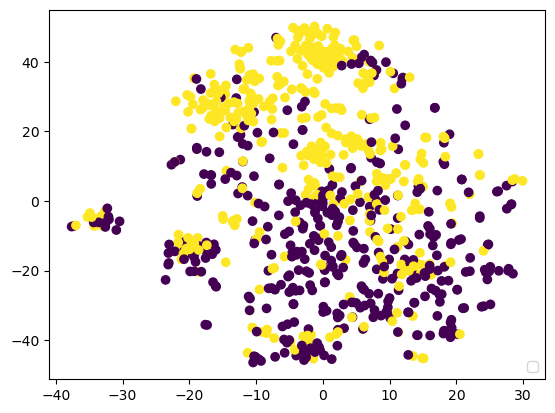

0
0    394
1    374
Name: count, dtype: int64
Training Accuracy: 0.9895833333333334
Training MCC Score: 0.9792113564307009
Training F1 Score: 0.9895788102475032
Training AUC VALUE: 0.9995792502510925
Training kappa Score: 0.979158186110885
Training Precision: 0.9841269841269841
Training Recall: 0.9946524064171123
Training Sensitivity: 0.9946524064171123
Training Specificity: 0.9847715736040609
Training CCR: 0.9895833333333334
Training PPV: 0.9841269841269841


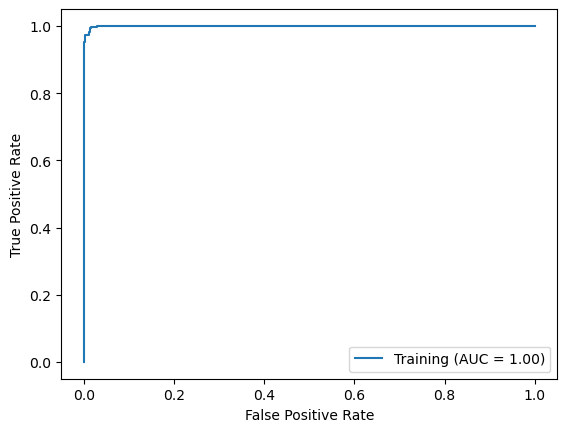

Testing Accuracy: 0.75
Testing MCC Score: 0.49961023769573576
Testing F1 Score: 0.7470967741935484
Testing AUC VALUE: 0.8255681818181818
Testing kappa Score: 0.496
Testing Precision: 0.7714285714285715
Testing Recall: 0.675
Testing Sensitivity: 0.675
Testing Specificity: 0.8181818181818182
Testing CCR: 0.75
Testing PPV: 0.7714285714285715


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


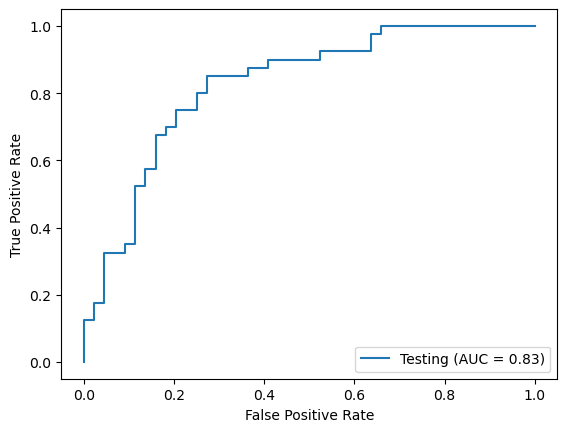

2024-11-04 22:11:11,029:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:11:11,030:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:11:11,030:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #2


C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


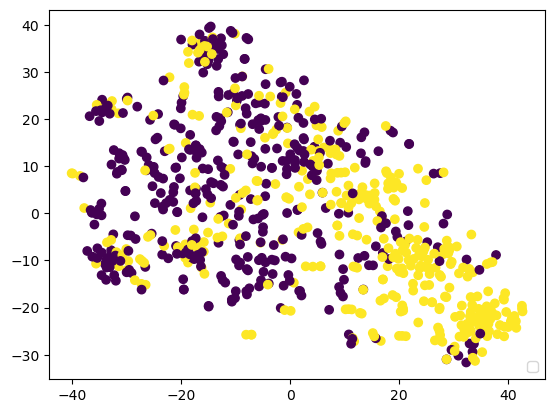

0
0    394
1    374
Name: count, dtype: int64
Training Accuracy: 0.984375
Training MCC Score: 0.968746190405964
Training F1 Score: 0.9843664122137404
Training AUC VALUE: 0.9991109964982764
Training kappa Score: 0.9687330365866899
Training Precision: 0.9813829787234043
Training Recall: 0.9866310160427807
Training Sensitivity: 0.9866310160427807
Training Specificity: 0.9822335025380711
Training CCR: 0.984375
Training PPV: 0.9813829787234043


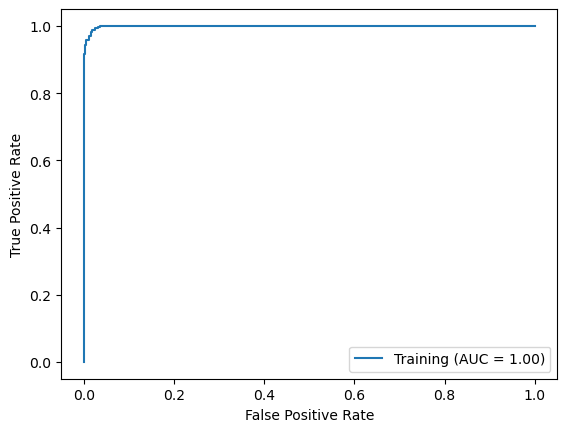

Testing Accuracy: 0.8214285714285714
Testing MCC Score: 0.6426343516463691
Testing F1 Score: 0.8212005108556834
Testing AUC VALUE: 0.8835227272727273
Testing kappa Score: 0.6424517593643586
Testing Precision: 0.8048780487804879
Testing Recall: 0.825
Testing Sensitivity: 0.825
Testing Specificity: 0.8181818181818182
Testing CCR: 0.8214285714285714
Testing PPV: 0.8048780487804879


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


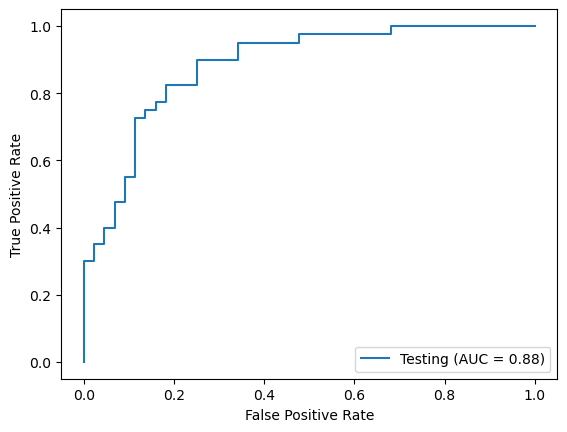

2024-11-04 22:11:13,412:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:11:13,413:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:11:13,414:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #3


C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


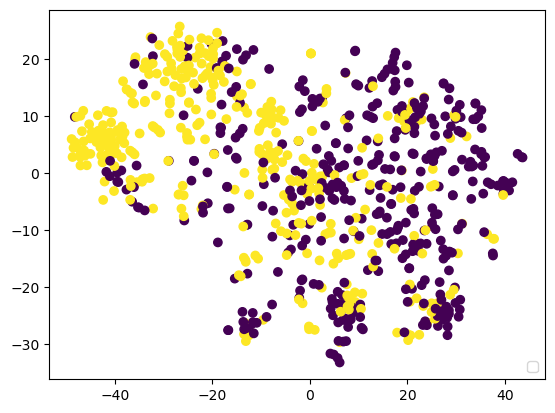

0
0    395
1    374
Name: count, dtype: int64
Training Accuracy: 0.9869960988296489
Training MCC Score: 0.9740329431395272
Training F1 Score: 0.9869897406745709
Training AUC VALUE: 0.9994246260069044
Training kappa Score: 0.9739801856914706
Training Precision: 0.9814814814814815
Training Recall: 0.9919786096256684
Training Sensitivity: 0.9919786096256684
Training Specificity: 0.9822784810126582
Training CCR: 0.9869960988296489
Training PPV: 0.9814814814814815


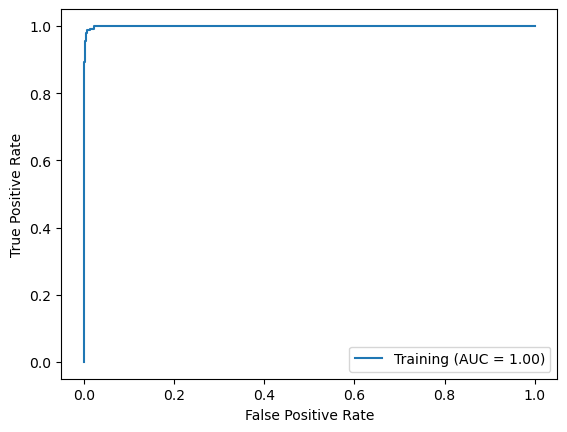

Testing Accuracy: 0.7228915662650602
Testing MCC Score: 0.4563748627883358
Testing F1 Score: 0.7147766323024054
Testing AUC VALUE: 0.7837209302325582
Testing kappa Score: 0.43968300557675377
Testing Precision: 0.7931034482758621
Testing Recall: 0.575
Testing Sensitivity: 0.575
Testing Specificity: 0.8604651162790697
Testing CCR: 0.7228915662650602
Testing PPV: 0.7931034482758621


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


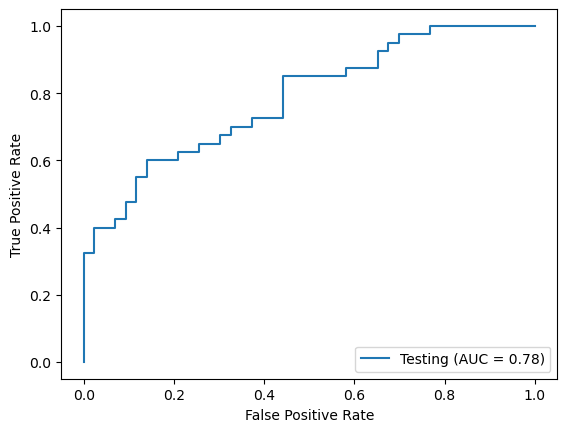

2024-11-04 22:11:15,820:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:11:15,821:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:11:15,822:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #4


C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


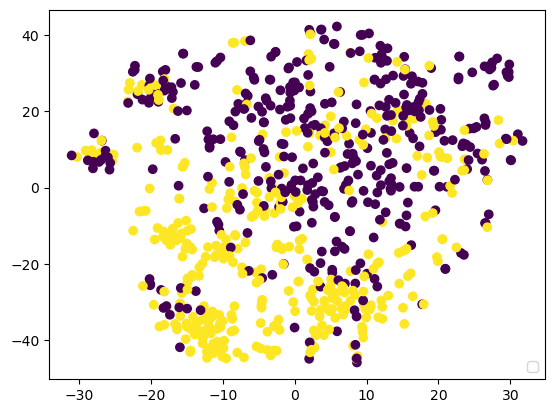

0
0    395
1    374
Name: count, dtype: int64
Training Accuracy: 0.988296488946684
Training MCC Score: 0.9765804814573336
Training F1 Score: 0.9882885672658601
Training AUC VALUE: 0.9996953902389494
Training kappa Score: 0.976577174166867
Training Precision: 0.9866666666666667
Training Recall: 0.9893048128342246
Training Sensitivity: 0.9893048128342246
Training Specificity: 0.9873417721518988
Training CCR: 0.988296488946684
Training PPV: 0.9866666666666667


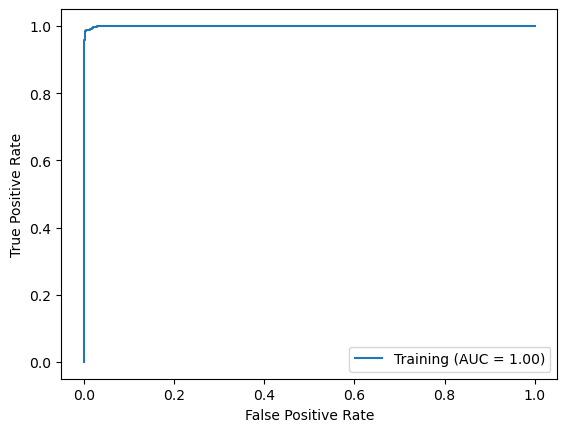

Testing Accuracy: 0.7831325301204819
Testing MCC Score: 0.5735867190200677
Testing F1 Score: 0.7792553191489362
Testing AUC VALUE: 0.8749999999999999
Testing kappa Score: 0.5626463700234192
Testing Precision: 0.84375
Testing Recall: 0.675
Testing Sensitivity: 0.675
Testing Specificity: 0.8837209302325582
Testing CCR: 0.7831325301204819
Testing PPV: 0.84375


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


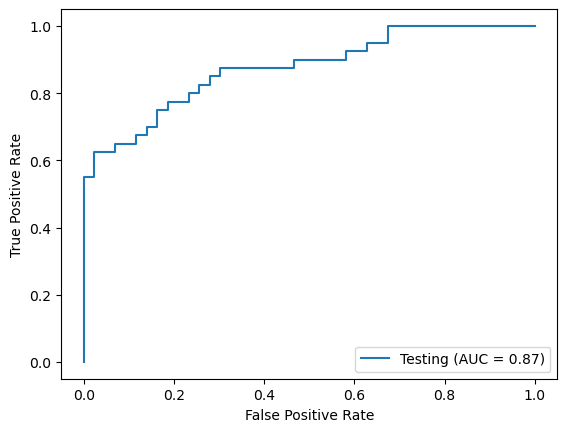

2024-11-04 22:11:18,294:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:11:18,295:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:11:18,295:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #5


C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


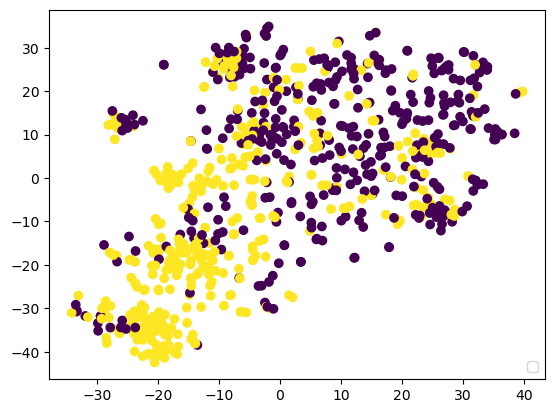

0
0    394
1    374
Name: count, dtype: int64
Training Accuracy: 0.9908854166666666
Training MCC Score: 0.9817921663563128
Training F1 Score: 0.9908809485441916
Training AUC VALUE: 0.9994706696707294
Training kappa Score: 0.981762175511921
Training Precision: 0.986737400530504
Training Recall: 0.9946524064171123
Training Sensitivity: 0.9946524064171123
Training Specificity: 0.9873096446700508
Training CCR: 0.9908854166666666
Training PPV: 0.986737400530504


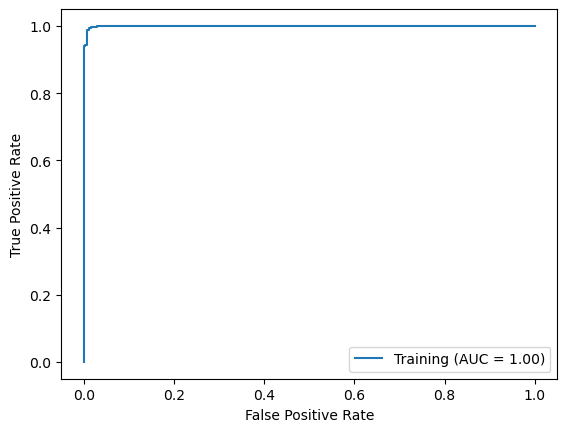

Testing Accuracy: 0.7710843373493976
Testing MCC Score: 0.5413274913757603
Testing F1 Score: 0.7705514331441874
Testing AUC VALUE: 0.8420745920745921
Testing kappa Score: 0.5411696246726797
Testing Precision: 0.75
Testing Recall: 0.7692307692307693
Testing Sensitivity: 0.7692307692307693
Testing Specificity: 0.7727272727272727
Testing CCR: 0.7710843373493976
Testing PPV: 0.75


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


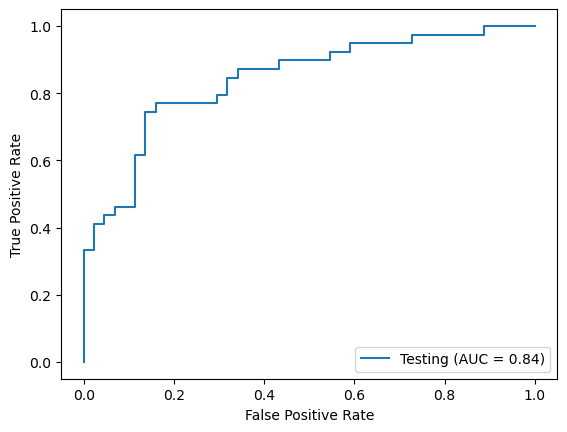

2024-11-04 22:11:20,686:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:11:20,686:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:11:20,687:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #6


C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


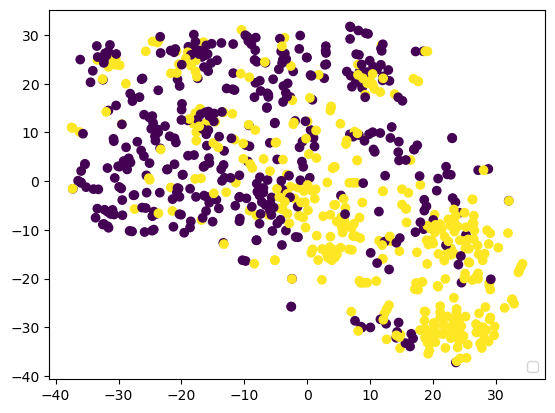

0
0    394
1    374
Name: count, dtype: int64
Training Accuracy: 0.9921875
Training MCC Score: 0.9843643964276989
Training F1 Score: 0.9921821982138495
Training AUC VALUE: 0.9995385325334564
Training kappa Score: 0.9843643964276989
Training Precision: 0.9919786096256684
Training Recall: 0.9919786096256684
Training Sensitivity: 0.9919786096256684
Training Specificity: 0.9923857868020305
Training CCR: 0.9921875
Training PPV: 0.9919786096256684


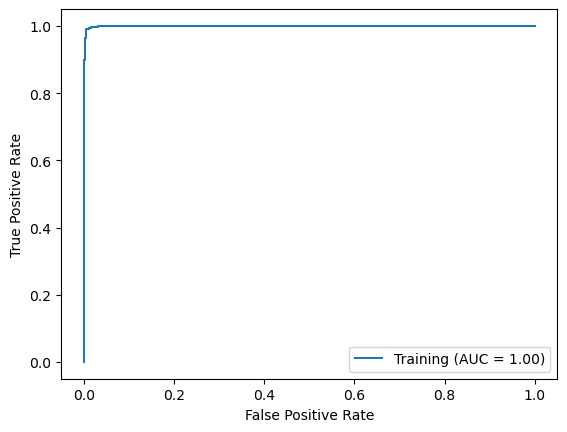

Testing Accuracy: 0.7710843373493976
Testing MCC Score: 0.539919491656399
Testing F1 Score: 0.7689377289377289
Testing AUC VALUE: 0.8374125874125874
Testing kappa Score: 0.5384840503365524
Testing Precision: 0.7777777777777778
Testing Recall: 0.717948717948718
Testing Sensitivity: 0.717948717948718
Testing Specificity: 0.8181818181818182
Testing CCR: 0.7710843373493976
Testing PPV: 0.7777777777777778


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


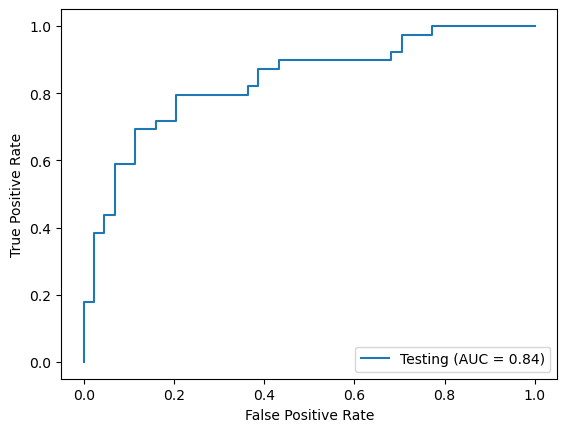

2024-11-04 22:11:23,080:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:11:23,081:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:11:23,082:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #7


C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


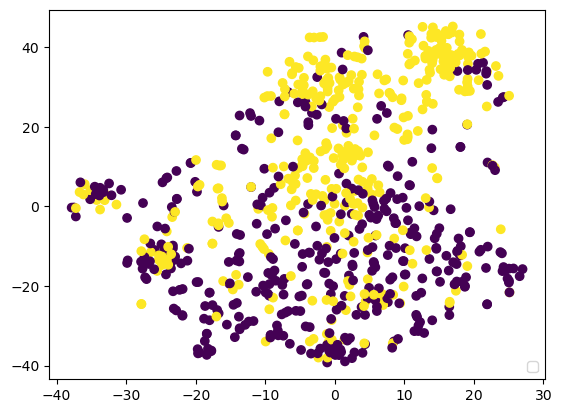

0
0    394
1    374
Name: count, dtype: int64
Training Accuracy: 0.9908854166666666
Training MCC Score: 0.9817630334143818
Training F1 Score: 0.9908798346970038
Training AUC VALUE: 0.9994774559570021
Training kappa Score: 0.9817597003379341
Training Precision: 0.9893333333333333
Training Recall: 0.9919786096256684
Training Sensitivity: 0.9919786096256684
Training Specificity: 0.9898477157360406
Training CCR: 0.9908854166666666
Training PPV: 0.9893333333333333


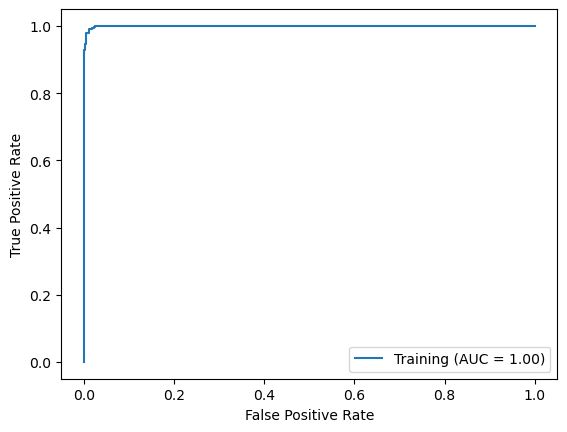

Testing Accuracy: 0.6746987951807228
Testing MCC Score: 0.3480793976803276
Testing F1 Score: 0.6739415102575295
Testing AUC VALUE: 0.7686480186480187
Testing kappa Score: 0.3479778876927553
Testing Precision: 0.65
Testing Recall: 0.6666666666666666
Testing Sensitivity: 0.6666666666666666
Testing Specificity: 0.6818181818181818
Testing CCR: 0.6746987951807228
Testing PPV: 0.65


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


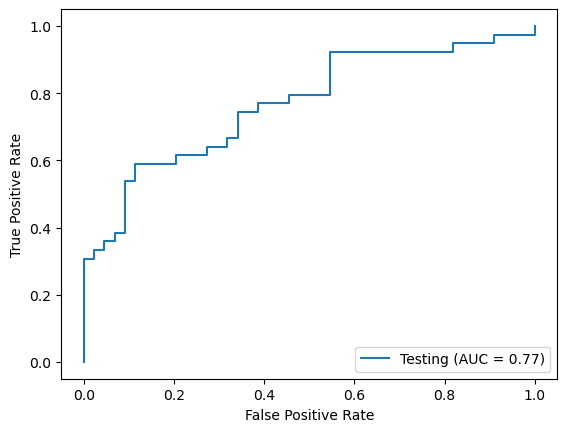

2024-11-04 22:11:25,483:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:11:25,484:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:11:25,484:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #8


C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


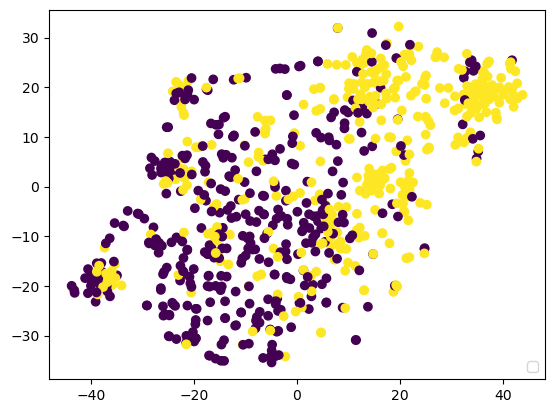

0
0    394
1    374
Name: count, dtype: int64
Training Accuracy: 0.9817708333333334
Training MCC Score: 0.963579147198582
Training F1 Score: 0.9817629179331306
Training AUC VALUE: 0.9989074079100954
Training kappa Score: 0.9635268256940487
Training Precision: 0.9761904761904762
Training Recall: 0.9866310160427807
Training Sensitivity: 0.9866310160427807
Training Specificity: 0.9771573604060914
Training CCR: 0.9817708333333334
Training PPV: 0.9761904761904762


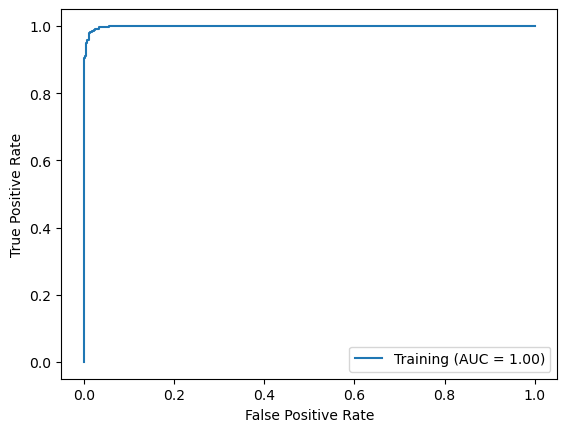

Testing Accuracy: 0.7710843373493976
Testing MCC Score: 0.5478874787140446
Testing F1 Score: 0.7643806962498133
Testing AUC VALUE: 0.831002331002331
Testing kappa Score: 0.5343962208444051
Testing Precision: 0.8333333333333334
Testing Recall: 0.6410256410256411
Testing Sensitivity: 0.6410256410256411
Testing Specificity: 0.8863636363636364
Testing CCR: 0.7710843373493976
Testing PPV: 0.8333333333333334


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


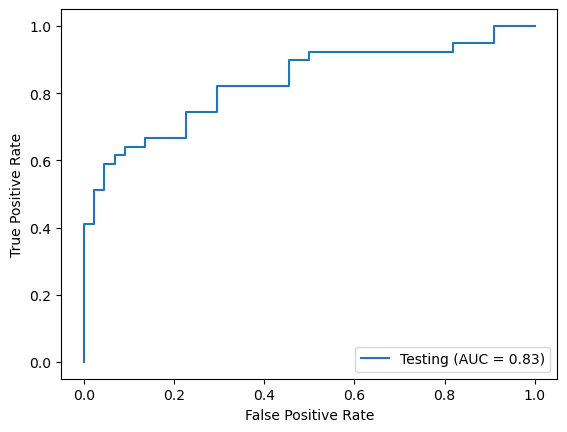

2024-11-04 22:11:27,870:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:11:27,871:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:11:27,871:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #9


C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


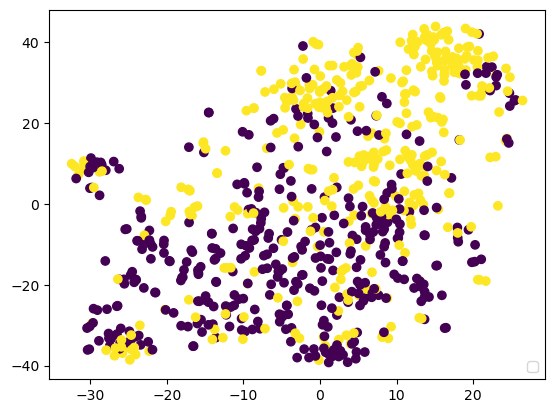

0
0    394
1    374
Name: count, dtype: int64
Training Accuracy: 0.9895833333333334
Training MCC Score: 0.9792000954305733
Training F1 Score: 0.9895731508634735
Training AUC VALUE: 0.9997014034040013
Training kappa Score: 0.9791468679573162
Training Precision: 0.9945945945945946
Training Recall: 0.983957219251337
Training Sensitivity: 0.983957219251337
Training Specificity: 0.9949238578680203
Training CCR: 0.9895833333333334
Training PPV: 0.9945945945945946


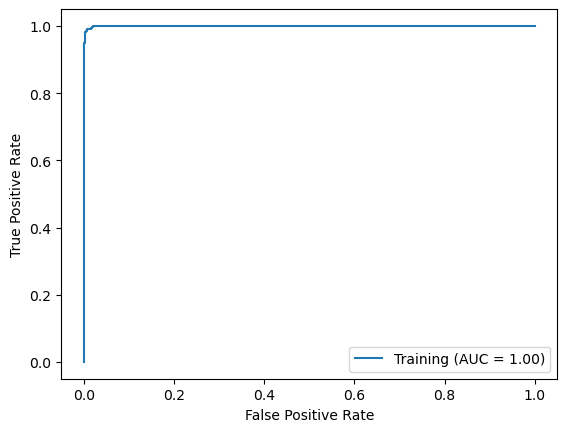

Testing Accuracy: 0.8072289156626506
Testing MCC Score: 0.6204953579462553
Testing F1 Score: 0.8023809523809524
Testing AUC VALUE: 0.8537296037296037
Testing kappa Score: 0.6084905660377358
Testing Precision: 0.8709677419354839
Testing Recall: 0.6923076923076923
Testing Sensitivity: 0.6923076923076923
Testing Specificity: 0.9090909090909091
Testing CCR: 0.8072289156626506
Testing PPV: 0.8709677419354839


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


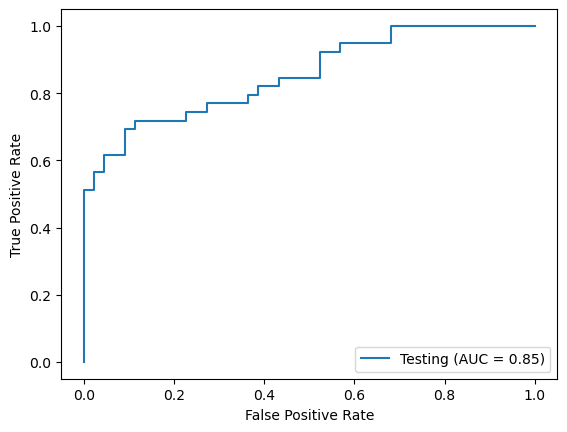

2024-11-04 22:11:30,271:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:11:30,272:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:11:30,272:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #10


C:\Users\DELL\AppData\Local\Temp\ipykernel_75528\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


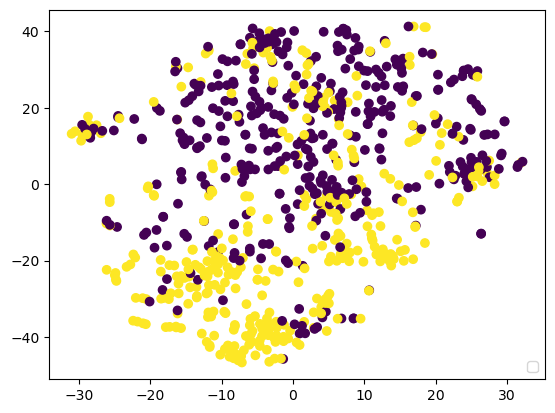

0
0    394
1    374
Name: count, dtype: int64
Training Accuracy: 0.9947916666666666
Training MCC Score: 0.9895882934382084
Training F1 Score: 0.9947873892829266
Training AUC VALUE: 0.9998507017020006
Training kappa Score: 0.9895748493239941
Training Precision: 0.9973118279569892
Training Recall: 0.9919786096256684
Training Sensitivity: 0.9919786096256684
Training Specificity: 0.9974619289340102
Training CCR: 0.9947916666666666
Training PPV: 0.9973118279569892


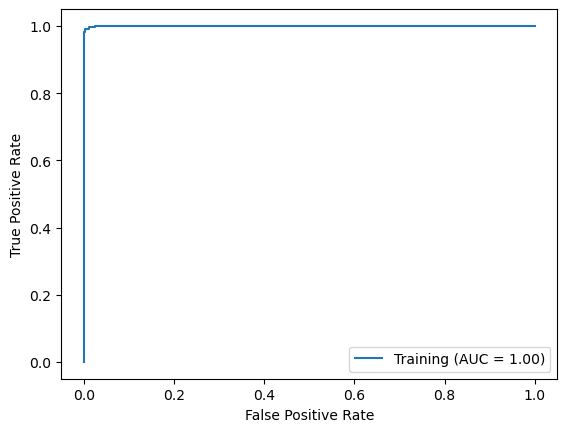

Testing Accuracy: 0.7951807228915663
Testing MCC Score: 0.5902478325709369
Testing F1 Score: 0.7921637943732509
Testing AUC VALUE: 0.8974358974358974
Testing kappa Score: 0.5858526562958615
Testing Precision: 0.8235294117647058
Testing Recall: 0.717948717948718
Testing Sensitivity: 0.717948717948718
Testing Specificity: 0.8636363636363636
Testing CCR: 0.7951807228915663
Testing PPV: 0.8235294117647058


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


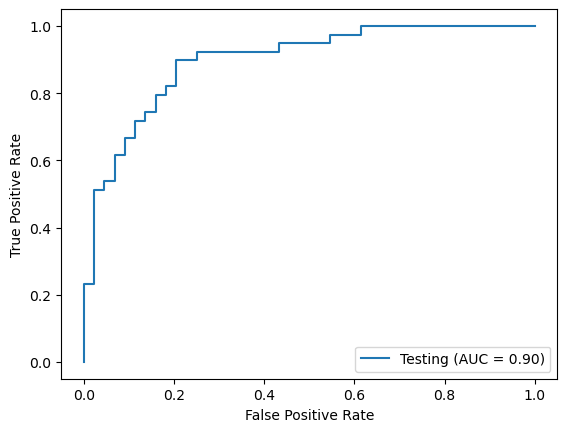

"\n    all_predictions = []\n    all_probabilities = []\n    all_labels = []\n    # 拼接训练集和测试集的预测结果和真实标签\n    all_predictions.extend(y_train_pred)\n    all_probabilities.extend(y_train_prob)\n    all_labels.extend(Final_Ytrain)\n    \n    all_predictions.extend(y_test_pred)\n    all_probabilities.extend(y_test_prob)\n    all_labels.extend(Test_y)\n\n    # 计算总的评价指标\n    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))\n"

In [37]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

Train_Fold_outs_1 = []
Test_Fold_outs_1 = []
models_1 = []

# 用于存储训练和测试集的预测结果和标签

total_metrics = []

# 定义 10 折交叉验证
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 获取特征和标签
X = Data[f_list].values  # 替换 Data 为你的数据集，f_list 为你的特征列表
y = Data['status'].values

Parameters = pd.DataFrame.from_dict(Best_params).iloc[13].to_dict()
print(Parameters)
# 10 折交叉验证
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f'Fold #{fold+1}')
    
    # 获取训练集和测试集
    Train_x, Test_x = X[train_index], X[test_index]
    Train_y, Test_y = y[train_index], y[test_index]
    
    # Upsampling
    Final_Xtrain, Final_Ytrain = Smote(pd.DataFrame(Train_x, columns=f_list), pd.Series(Train_y), 0.5)
    print(Final_Ytrain.value_counts())
    Final_Ytrain = Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype=np.float64)
    Test_x_filtered = pd.DataFrame(Test_x, dtype=np.float64)

    # 使用 KNeighborsClassifier
    rf = RandomForestClassifier(max_features=Parameters['max_features'],
                        max_depth=Parameters['max_depth'],
                        min_samples_split=Parameters['min_samples_split'],
                        min_samples_leaf=Parameters['min_samples_leaf'],
                        bootstrap=Parameters['bootstrap'],
                        n_estimators=Parameters['n_estimators'])

    
    # 拟合模型
    rf.fit(Final_Xtrain, Final_Ytrain)
    models_1.append(rf)
    
    # 训练集预测
    y_train_pred = rf.predict(Final_Xtrain)
    y_train_prob = rf.predict_proba(Final_Xtrain)[:, 1]
    Train_Fold_outs_1.append(Scoring_metrices(y_train_pred, y_train_prob, Final_Ytrain, 'Training'))

    # 测试集预测
    y_test_pred = rf.predict(Test_x_filtered)
    y_test_prob = rf.predict_proba(Test_x_filtered)[:, 1]
    Test_Fold_outs_1.append(Scoring_metrices(y_test_pred, y_test_prob, Test_y, 'Testing'))
'''
    all_predictions = []
    all_probabilities = []
    all_labels = []
    # 拼接训练集和测试集的预测结果和真实标签
    all_predictions.extend(y_train_pred)
    all_probabilities.extend(y_train_prob)
    all_labels.extend(Final_Ytrain)
    
    all_predictions.extend(y_test_pred)
    all_probabilities.extend(y_test_prob)
    all_labels.extend(Test_y)

    # 计算总的评价指标
    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))
'''

In [38]:
#Analyse the training metrics sorted by descending Training Accuracy
pd.DataFrame.from_dict(Test_Fold_outs_1).sort_values(by=['Testing kappa Score:'],ascending = False)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
1,0.821429,0.642634,0.821201,0.883523,0.642452,0.804878,0.825000,0.825000,0.818182,0.821429,0.804878
8,0.807229,0.620495,0.802381,0.853730,0.608491,0.870968,0.692308,0.692308,0.909091,0.807229,0.870968
9,0.795181,0.590248,0.792164,0.897436,0.585853,0.823529,0.717949,0.717949,0.863636,0.795181,0.823529
3,0.783133,0.573587,0.779255,0.875000,0.562646,0.843750,0.675000,0.675000,0.883721,0.783133,0.843750
4,0.771084,0.541327,0.770551,0.842075,0.541170,0.750000,0.769231,0.769231,0.772727,0.771084,0.750000
5,0.771084,0.539919,0.768938,0.837413,0.538484,0.777778,0.717949,0.717949,0.818182,0.771084,0.777778
7,0.771084,0.547887,0.764381,0.831002,0.534396,0.833333,0.641026,0.641026,0.886364,0.771084,0.833333
0,0.750000,0.499610,0.747097,0.825568,0.496000,0.771429,0.675000,0.675000,0.818182,0.750000,0.771429
2,0.722892,0.456375,0.714777,0.783721,0.439683,0.793103,0.575000,0.575000,0.860465,0.722892,0.793103
6,0.674699,0.348079,0.673942,0.768648,0.347978,0.650000,0.666667,0.666667,0.681818,0.674699,0.650000


<Axes: >

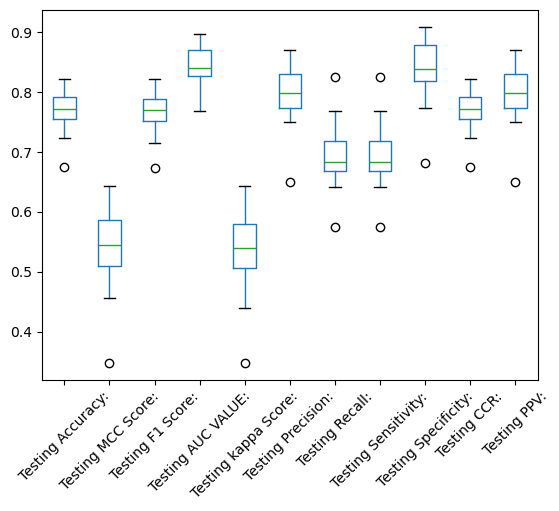

In [39]:
#To visualize the stability of the tuned model with each fold
(pd.DataFrame(Test_Fold_outs_1)).boxplot(grid=False,rot=45)

In [40]:
pd.DataFrame(Test_Fold_outs_1)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
0,0.750000,0.499610,0.747097,0.825568,0.496000,0.771429,0.675000,0.675000,0.818182,0.750000,0.771429
1,0.821429,0.642634,0.821201,0.883523,0.642452,0.804878,0.825000,0.825000,0.818182,0.821429,0.804878
2,0.722892,0.456375,0.714777,0.783721,0.439683,0.793103,0.575000,0.575000,0.860465,0.722892,0.793103
3,0.783133,0.573587,0.779255,0.875000,0.562646,0.843750,0.675000,0.675000,0.883721,0.783133,0.843750
4,0.771084,0.541327,0.770551,0.842075,0.541170,0.750000,0.769231,0.769231,0.772727,0.771084,0.750000
5,0.771084,0.539919,0.768938,0.837413,0.538484,0.777778,0.717949,0.717949,0.818182,0.771084,0.777778
6,0.674699,0.348079,0.673942,0.768648,0.347978,0.650000,0.666667,0.666667,0.681818,0.674699,0.650000
7,0.771084,0.547887,0.764381,0.831002,0.534396,0.833333,0.641026,0.641026,0.886364,0.771084,0.833333
8,0.807229,0.620495,0.802381,0.853730,0.608491,0.870968,0.692308,0.692308,0.909091,0.807229,0.870968
9,0.795181,0.590248,0.792164,0.897436,0.585853,0.823529,0.717949,0.717949,0.863636,0.795181,0.823529


In [41]:
TRAIN = Data.drop(['smiles','status'],axis=1)
TRAIN

,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,A1_9,...,E5_118,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127
0,0.093736,0.085746,0.093669,-0.093733,-0.093736,-0.093322,0.093736,-0.093720,-0.093735,0.059581,...,-0.026415,0.119321,-0.005243,-0.015744,-0.010452,0.022232,0.016749,0.094246,-0.123218,-0.099457
1,-0.093479,-0.089258,0.069801,-0.090986,-0.082043,-0.043359,0.091742,-0.093448,0.089061,0.093108,...,-0.090673,-0.116404,0.065310,-0.059638,0.008421,-0.018185,-0.046916,-0.002449,0.137647,0.030377
2,-0.098335,-0.081193,0.049595,-0.061777,-0.066672,-0.022043,0.087456,-0.098040,0.047128,0.098288,...,-0.105842,-0.059380,-0.026610,0.045300,-0.068234,0.028847,-0.068210,0.011231,0.146784,-0.091332
3,-0.094336,-0.094267,-0.061746,-0.030467,-0.084787,-0.086779,0.066083,-0.093192,0.082983,0.091931,...,-0.096881,-0.104732,0.103063,0.032510,0.105347,-0.053153,0.019736,-0.092859,0.018258,0.047839
4,-0.096464,0.053822,-0.087383,0.095549,-0.091416,0.096470,0.096480,-0.096477,-0.077987,-0.029744,...,-0.012364,-0.118487,-0.006075,0.104476,0.081948,-0.120817,-0.001020,-0.131218,0.095820,-0.004740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,-0.094703,0.053805,-0.077123,-0.091058,-0.023716,0.094684,0.094702,-0.094285,0.024496,-0.090858,...,-0.074208,-0.114031,0.127189,0.042291,-0.014169,-0.023058,-0.011703,-0.104163,0.136681,-0.034235
828,-0.100327,0.096046,0.100504,0.069730,0.099986,0.100672,-0.004291,-0.100666,-0.038768,0.100514,...,-0.085273,0.095722,0.010054,0.064335,0.077486,0.113237,0.079145,0.066059,0.052996,-0.014950
829,-0.096752,0.042767,-0.042472,-0.077850,-0.091364,0.095093,0.096676,-0.095219,-0.047272,-0.040468,...,-0.129808,-0.097304,0.075988,-0.050639,-0.064332,0.052469,-0.025119,-0.053081,0.129570,0.024581
830,-0.081419,0.101078,-0.099647,0.044550,-0.009900,0.103883,0.101900,-0.100953,-0.053084,-0.014191,...,-0.142667,0.068415,-0.097630,0.035883,0.006858,-0.021862,0.024690,0.098589,-0.101587,0.060199


In [42]:
TRAIN = TRAIN[f_list] #Use features of the selected (hyperparameter tuned) model here
TRAIN

,A2_123,A5_93,B2_12,B2_38,B2_40,B2_102,B3_9,B3_19,B3_20,B3_22,...,E4_111,E4_113,E4_117,E4_120,E4_122,E4_125,E5_3,E5_13,E5_87,E5_110
0,-0.096565,0.078355,0.138966,-0.049364,-0.120079,0.033303,-0.024736,0.049656,0.083204,-0.091069,...,0.036509,0.099780,0.104410,-0.093174,0.104501,-0.104382,0.084489,-0.128348,0.088636,0.093612
1,0.065567,0.092401,0.119728,0.073669,-0.133427,-0.059130,0.121791,0.128314,-0.019653,-0.112681,...,-0.021647,-0.065752,0.073527,-0.082653,0.115730,-0.051649,0.051750,0.069493,0.030170,0.084704
2,0.036213,0.096653,0.037637,-0.070598,0.041552,-0.070308,0.129522,0.124847,0.133294,-0.114680,...,-0.021484,0.057832,0.062109,0.073452,0.134571,-0.046167,-0.106255,0.098720,0.022950,0.002907
3,0.084745,0.093098,0.125209,-0.121608,0.001023,0.097020,0.112987,0.075185,0.103909,-0.057657,...,-0.006257,0.054363,0.106258,-0.013995,0.106495,-0.094931,-0.091218,-0.049833,0.114151,0.044409
4,-0.095734,-0.093199,0.066266,0.118769,0.043535,-0.154152,0.107936,0.103807,-0.031419,-0.071594,...,0.003088,0.061197,0.070241,-0.104320,0.129967,-0.115071,-0.101588,0.049238,0.103533,0.064990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,-0.098888,0.090318,0.010489,0.011098,-0.017839,-0.054068,0.075147,0.089011,0.139110,0.097010,...,-0.072163,0.124000,0.120606,-0.106562,0.120408,-0.088434,0.013804,0.084146,0.096133,0.112750
828,-0.100499,0.094584,-0.025546,-0.043293,0.090932,-0.055262,-0.105227,0.012788,0.039535,-0.090036,...,-0.072261,0.107191,0.109612,-0.099616,0.109642,-0.107911,0.101091,-0.095738,0.102343,0.119745
829,-0.101874,0.090927,0.064962,0.056303,0.042924,-0.087365,0.095772,-0.028430,0.126434,0.120370,...,-0.105451,0.108576,0.109586,-0.106946,0.109579,-0.102763,0.066411,0.104395,0.024950,0.080082
830,-0.104687,-0.053587,0.103188,-0.118127,0.090844,0.054935,0.063951,-0.124844,0.135161,0.108301,...,0.110956,0.118703,0.089054,0.059335,0.065277,-0.098176,0.000938,-0.096217,0.103192,-0.091792


In [43]:
Y = Data['status']

In [45]:
#Fitting the model on whole data
fitted = models_1[1].fit(TRAIN,Y)
fitted

RandomForestClassifier(max_depth=90.0, max_features=None, min_samples_leaf=2,
                       min_samples_split=12, n_estimators=67)

In [46]:
#Save the final model
joblib.dump(fitted, 'AID_1194_RF.pkl')

['AID_1194_RF.pkl']

In [47]:
import joblib
import pandas as pd

class model_AID_1194:
    def __init__(self, test):        
        self.test = test

    def extract_feature(self, data):        
        # 读取特征文件
        F_names = pd.read_csv('AID_1194_features.csv')
        features = F_names.iloc[:, 0].tolist()
        return data[features]

    def get_labels(self, pred_test):
        # 根据概率预测类别
        test_pred = []
        for i in range(pred_test.shape[0]):
            if pred_test[i][0] > pred_test[i][1]:  # 类别 0 概率更大
                test_pred.append(0)
            else:
                test_pred.append(1)  # 类别 1 概率更大
        return test_pred

    def test_model(self):
        # 提取特征并加载本地的 KNN 模型进行预测
        test = self.test
        test_filtered = self.extract_feature(test.drop(['smiles'], axis=1))
        
        # 本地加载 KNN 模型
        model = joblib.load('AID_1194_RF.pkl')
        
        # 使用模型进行预测
        probs = model.predict_proba(test_filtered)
        
        # 获取预测类别
        preds = self.get_labels(probs)
        
        return probs, preds


def AID_1194(smi_list):
    Feature_data = pd.DataFrame()
    Feature_data['smiles'] = smi_list

    Sig_Carcin = Feature_Signaturizer(smi_list)
    
    # 保留删除前的索引
    original_index = Sig_Carcin.index
    
    # 删除缺失值的行
    Sig_Carcin_clean = Sig_Carcin.dropna()

    # 使用清理过的数据进行模型测试
    m4 = model_AID_1194(Sig_Carcin_clean)  # 假设这里的模型函数改为 model_apoptosis
    probs, preds = m4.test_model()

    # 创建一个与原始索引匹配的结果数组
    Feature_data['AID_1194_0'] = None
    Feature_data['AID_1194_1'] = None
    Feature_data['AID_1194_preds'] = None

    # 填充有效的预测结果
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1194_0'] = probs[:, 0]
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1194_1'] = probs[:, 1]
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1194_preds'] = preds

    return Feature_data


In [19]:
# 指定当前的工作文件夹
import os
# 此处为google drive中的文件路径,drive为之前指定的工作根目录，要加上
os.chdir("C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao")
#load preprocessed feature file here
data = pd.read_csv(r'MKETn_Training_Data.csv') ### features in columns,molecules in rows
data

,SMILES,Name,CID,InChI,IUPAC,Status,Source
0,[As],Arsenic,5359596.0,1S/As,arsenic,1,CCRIS
1,[Be],Beryllium,5460467.0,1S/Be,beryllium,1,CCRIS
2,[Be]=O,Beryllium oxide,14775.0,1S/Be.O,oxoberyllium,1,CCRIS
3,[Be+2].[OH-].[OH-],Dihydroxyberyllium,25879.0,1S/Be.2H2O/h;2*1H2/q+2;;/p-2,beryllium;dihydroxide,1,CCRIS
4,[C-]#[Si+],Silicon carbide,9863.0,1S/CSi/c1-2,methanidylidynesilanylium,1,CCRIS
...,...,...,...,...,...,...,...
461,P#[Ga],Gallium phosphide,82901.0,1S/Ga.P,gallanylidynephosphane,0,CCRIS
462,S=[Cd],Cadmium sulfide,14783.0,1S/Cd.S,sulfanylidenecadmium,1,CCRIS
463,S=[Ni],Nickel sulfide,28094.0,1S/Ni.S,sulfanylidenenickel,1,CCRIS
464,S=P(N1CC1)(N1CC1)N1CCOCC1,Morzid,62432.0,"1S/C8H16N3OPS/c14-13(9-1-2-9,10-3-4-10)11-5-7-...",bis(aziridin-1-yl)-morpholin-4-yl-sulfanyliden...,1,CCRIS
